# OOT Delinquency Backtest Evaluation

True out-of-time backtest for the roll-rate Markov chain model.

Scope:
- Train only on older vintages
- Predict holdout vintages from an anchor MOB
- Evaluate both `DEL30` and `DEL90`
- Report path-level `MAE`, `RMSE`, `Brier` and loan-level `Brier` at target MOBs
- Produce diagnostic charts for calibration, error concentration, and K-curve behavior


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['savefig.dpi'] = 140

from src.data_loader import load_data
import src.config as project_config
from src.rollrate.oot_evaluation import (
    run_dual_metric_oot_backtest,
    run_rolling_mature_oot_backtest,
    run_del90_k_variant_comparison,
    run_del90_asof_calibrated_backtest,
    run_del90_portfolio_asof_grid,
)


## Parameters

Adjust this cell first. Defaults below are aligned with the current NTB workflow and keep the evaluation focused on a real holdout split by vintage.


In [2]:
DATA_PATH_CANDIDATES = [
    project_root.parent / 'NTB_Parquet_NTBV3_NEWRG',
    project_root / 'NTB_Parquet_NTBV3_NEWRG',
    project_root / 'data' / 'NTB_Parquet_NTBV3_NEWRG',
]

DATA_PATH = next((str(path) for path in DATA_PATH_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'Cannot resolve NTB parquet directory. Checked: ' +
        ', '.join(str(path) for path in DATA_PATH_CANDIDATES)
    )

PRODUCT_FILTER = None
RISK_FILTER = None

HOLDOUT_MONTHS = 6
MIN_TRAIN_VINTAGES = 12
MAX_MOB_EVAL = 24
ANCHOR_MOB = 0
TARGET_MOBS = [12, 24]

MATURE_TARGET_MOBS = [12, 24]
MATURE_HOLDOUT_MONTHS = 6
MAX_MATURE_WINDOWS_PER_TARGET = 2

DEL90_VARIANT_TARGET_MOB = 12
DEL90_BLEND_WEIGHTS = [0.5]

ASOF_TARGET_MOB = 12
ASOF_LOOKBACK_MONTHS = 8
ASOF_CALIBRATION_N_VINTAGES = 1
# Must match the production run in Group_Master_Total.ipynb.
MODEL_SEGMENT_COLS = ['PRODUCT_TYPE', 'RISK_SCORE', 'SALE_CHANNEL', 'GENDER']
# create_segment_columns() collapses non-product dimensions into composite RISK_SCORE.
ASOF_CALIBRATION_GROUP_COLS = ['PRODUCT_TYPE', 'RISK_SCORE']
ASOF_CALIBRATION_SHRINK = 1.0
ASOF_RESIDUAL_CAP = 0.10

PORTFOLIO_GRID_ANCHOR_MOBS = [2, 4, 6, 8]
PORTFOLIO_GRID_TARGET_N_VINTAGES = 8
PORTFOLIO_GRID_CALIBRATION_N_VINTAGES = 3

FIT_PARAMS = {
    'k_method': 'wls_reg',
    'lambda_k': 1e-4,
    'k_prior': 0.0,
    'k_min_obs': 5,
    'fallback_k': 1.0,
    'fallback_weight': 0.0,
    'gamma': 10.0,
    'alpha_mob_target': max(TARGET_MOBS) if TARGET_MOBS else MAX_MOB_EVAL,
    'k_weight_mode': 'equal',
    'monotone': False,
}

SETTINGS_OVERRIDES = {
    'segment_cols': list(MODEL_SEGMENT_COLS),
    'roll_window': project_config.CFG.get('ROLL_WINDOW'),
    'decay_lambda': project_config.CFG.get('DECAY_LAMBDA'),
    'weight_method': project_config.CFG.get('WEIGHT_METHOD', getattr(project_config, 'WEIGHT_METHOD', 'exp')),
    'min_obs': project_config.CFG.get('MIN_OBS', 100),
    'min_ead': project_config.CFG.get('MIN_EAD', 100.0),
    'k_post_mature': project_config.K_POST_MATURE,
    'k_post_mature_del90': project_config.K_POST_MATURE_DEL90,
}

OUTPUT_DIR = project_root / 'notebooks' / 'outputs' / 'oot_backtest_ntb'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Resolved DATA_PATH =', DATA_PATH)
OUTPUT_DIR


Resolved DATA_PATH = D:\backup_ổ c\NTB_Parquet_NTBV3_NEWRG


WindowsPath('D:/backup_ổ c/RR_model_1911_Projection/notebooks/outputs/oot_backtest_ntb')

## Metric Definition Notes

- Path-level `MAE`, `RMSE`, `Brier` compare predicted cohort delinquency rate vs actual cohort delinquency rate across holdout `(product, score, vintage, mob)` observations.
- Loan-level `Brier` is the true binary Brier score at each target MOB, using cohort forecast probability assigned to each holdout loan and actual delinquency outcome observed at that target MOB.
- `DEL30` and `DEL90` are fit separately in the same way production now does.


In [3]:
def pct_points(series):
    return series * 100.0


def weighted_group_error(compare_df, group_col):
    if compare_df.empty:
        return pd.DataFrame(columns=[group_col, 'W_MAE', 'W_RMSE', 'N_OBS'])
    rows = []
    for value, grp in compare_df.groupby(group_col):
        weights = grp['DISB_TOTAL'].fillna(0.0).astype(float).values
        abs_err = grp['ABS_ERROR'].astype(float).values
        sq_err = grp['SQ_ERROR'].astype(float).values
        if np.any(weights > 0):
            w_mae = np.average(abs_err, weights=weights)
            w_rmse = np.sqrt(np.average(sq_err, weights=weights))
        else:
            w_mae = abs_err.mean()
            w_rmse = np.sqrt(sq_err.mean())
        rows.append({group_col: value, 'W_MAE': w_mae, 'W_RMSE': w_rmse, 'N_OBS': len(grp)})
    return pd.DataFrame(rows).sort_values('W_MAE', ascending=False)


def build_calibration_bins(df, pred_col, actual_col, weight_col=None, n_bins=10):
    data = df[[pred_col, actual_col] + ([weight_col] if weight_col else [])].dropna().copy()
    if data.empty:
        return pd.DataFrame(columns=['BIN', 'PRED_MEAN', 'ACTUAL_MEAN', 'COUNT'])
    n_unique = data[pred_col].nunique()
    q = max(1, min(int(n_bins), int(n_unique)))
    if q == 1:
        data['BIN'] = 'ALL'
    else:
        data['BIN'] = pd.qcut(data[pred_col].rank(method='first'), q=q, duplicates='drop')
    rows = []
    for bin_name, grp in data.groupby('BIN', observed=False):
        if weight_col and np.any(grp[weight_col].fillna(0.0).astype(float).values > 0):
            weights = grp[weight_col].fillna(0.0).astype(float).values
            pred_mean = np.average(grp[pred_col], weights=weights)
            actual_mean = np.average(grp[actual_col], weights=weights)
        else:
            pred_mean = grp[pred_col].mean()
            actual_mean = grp[actual_col].mean()
        rows.append({
            'BIN': str(bin_name),
            'PRED_MEAN': pred_mean,
            'ACTUAL_MEAN': actual_mean,
            'COUNT': len(grp),
        })
    return pd.DataFrame(rows)


def top_error_rows(compare_df, n=15):
    cols = ['PRODUCT_TYPE', 'RISK_SCORE', 'VINTAGE_DATE', 'MOB', 'DISB_TOTAL', 'ACTUAL_PCT', 'PRED_PCT', 'ERROR', 'ABS_ERROR']
    if compare_df.empty:
        return pd.DataFrame(columns=cols)
    return compare_df.sort_values('ABS_ERROR', ascending=False)[cols].head(n).copy()


def save_result_tables(results_bundle, output_dir):
    results_bundle['split_summary_df'].to_csv(output_dir / 'split_summary.csv', index=False)
    results_bundle['summary_df'].to_csv(output_dir / 'path_metric_summary.csv', index=False)
    results_bundle['loan_brier_summary_df'].to_csv(output_dir / 'loan_brier_summary.csv', index=False)
    for metric_name, metric_result in results_bundle['metric_results'].items():
        metric_result['compare_df'].to_csv(output_dir / f'{metric_name.lower()}_path_compare.csv', index=False)
        metric_result['summary_df'].to_csv(output_dir / f'{metric_name.lower()}_path_summary.csv', index=False)
        metric_result['fit_output']['k_curve_df'].to_csv(output_dir / f'{metric_name.lower()}_k_curve.csv', index=False)
        if not metric_result['loan_brier_df'].empty:
            metric_result['loan_brier_df'].to_csv(output_dir / f'{metric_name.lower()}_loan_brier_detail.csv', index=False)
        if not metric_result['loan_brier_summary_df'].empty:
            metric_result['loan_brier_summary_df'].to_csv(output_dir / f'{metric_name.lower()}_loan_brier_summary.csv', index=False)



def save_mature_result_tables(mature_results, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)
    mature_results['windows_catalog_df'].to_csv(output_dir / 'windows_catalog.csv', index=False)
    mature_results['path_summary_by_window_df'].to_csv(output_dir / 'path_summary_by_window.csv', index=False)
    mature_results['mature_path_summary_df'].to_csv(output_dir / 'mature_path_summary.csv', index=False)
    if not mature_results['loan_brier_summary_by_window_df'].empty:
        mature_results['loan_brier_summary_by_window_df'].to_csv(output_dir / 'loan_brier_summary_by_window.csv', index=False)
    if not mature_results['mature_loan_brier_summary_df'].empty:
        mature_results['mature_loan_brier_summary_df'].to_csv(output_dir / 'mature_loan_brier_summary.csv', index=False)
    if not mature_results['mature_compare_df'].empty:
        mature_results['mature_compare_df'].to_csv(output_dir / 'mature_compare_detail.csv', index=False)
    if not mature_results['mature_loan_brier_df'].empty:
        mature_results['mature_loan_brier_df'].to_csv(output_dir / 'mature_loan_brier_detail.csv', index=False)


In [4]:
df_raw = load_data(DATA_PATH)

results = run_dual_metric_oot_backtest(
    df_raw,
    holdout_months=HOLDOUT_MONTHS,
    min_train_vintages=MIN_TRAIN_VINTAGES,
    max_mob_eval=MAX_MOB_EVAL,
    anchor_mob=ANCHOR_MOB,
    target_mobs=TARGET_MOBS,
    product_filter=PRODUCT_FILTER,
    risk_filter=RISK_FILTER,
    fit_params=FIT_PARAMS,
    settings_overrides=SETTINGS_OVERRIDES,
)

save_result_tables(results, OUTPUT_DIR)

split_summary_df = results['split_summary_df'].copy()
path_summary_df = results['summary_df'].copy()
loan_brier_summary_df = results['loan_brier_summary_df'].copy()

split_summary_df


📦 Loading Parquet from: D:\backup_ổ c\NTB_Parquet_NTBV3_NEWRG
⚠️ pyarrow.dataset not used (Integer value 166 not in range: -128 to 127). Falling back to glob concat...
✅ Loaded 3,902,510 rows from 38/38 files
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=E, score=H)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=E, score=L)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=E, score=M)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=E, score=nan)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=F, score=H)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=F, score=L)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=F, score=M)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']

,CUT_OFF_HOLDOUT_VINTAGE,N_TRAIN_VINTAGES,N_HOLDOUT_VINTAGES,TRAIN_ROWS,HOLDOUT_ROWS,TRAIN_LOANS,HOLDOUT_LOANS,TRAIN_DISB_TOTAL,HOLDOUT_DISB_TOTAL
0,2025-09-01,32,6,3858801,43709,178892,11175,119545.046875,1671.856934


## Train / Holdout Split

This chart verifies the split is truly out-of-time by vintage.


,CUT_OFF_HOLDOUT_VINTAGE,N_TRAIN_VINTAGES,N_HOLDOUT_VINTAGES,TRAIN_ROWS,HOLDOUT_ROWS,TRAIN_LOANS,HOLDOUT_LOANS,TRAIN_DISB_TOTAL,HOLDOUT_DISB_TOTAL
0,2025-09-01,32,6,3858801,43709,178892,11175,119545.046875,1671.856934


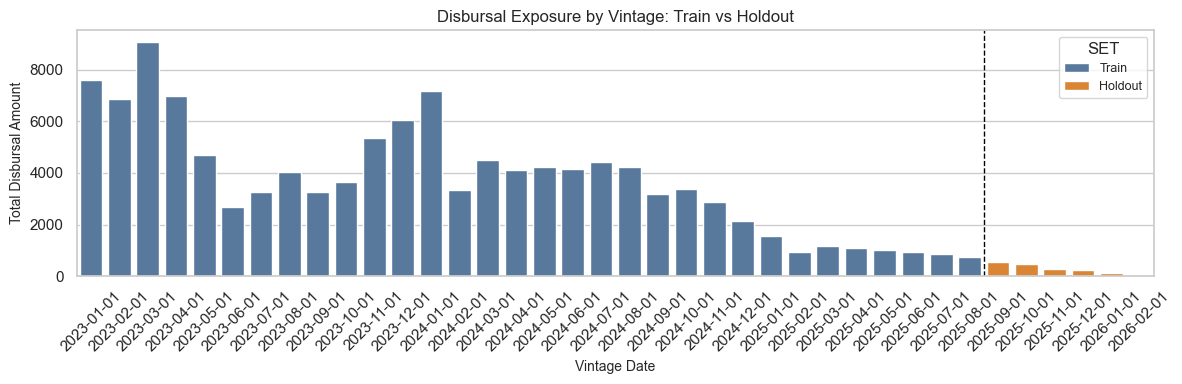

In [5]:
display(split_summary_df)

vintage_disb = (
    results['df_model']
    .groupby('VINTAGE_DATE', as_index=False)['DISBURSAL_AMOUNT']
    .sum()
    .sort_values('VINTAGE_DATE')
)
cutoff_vintage = pd.Timestamp(results['split_info']['cutoff_vintage'])
vintage_disb['SET'] = np.where(vintage_disb['VINTAGE_DATE'] < cutoff_vintage, 'Train', 'Holdout')

plt.figure(figsize=(12, 4))
sns.barplot(data=vintage_disb, x='VINTAGE_DATE', y='DISBURSAL_AMOUNT', hue='SET', palette={'Train': '#4C78A8', 'Holdout': '#F58518'})
plt.axvline(vintage_disb.index[vintage_disb['VINTAGE_DATE'] >= cutoff_vintage][0] - 0.5, color='black', linestyle='--', linewidth=1)
plt.xticks(rotation=45)
plt.title('Disbursal Exposure by Vintage: Train vs Holdout')
plt.xlabel('Vintage Date')
plt.ylabel('Total Disbursal Amount')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'split_train_holdout_exposure.png', bbox_inches='tight')
plt.show()


## Core Metrics

`MAE`, `RMSE`, `Brier` below are path-level metrics on holdout cohort observations. For readability, the rate metrics are also shown in percentage points.


In [6]:
path_summary_display = path_summary_df.copy()
for col in ['MAE', 'RMSE', 'BRIER', 'WEIGHTED_MAE', 'WEIGHTED_RMSE', 'WEIGHTED_BRIER', 'BIAS', 'CORR']:
    if col in path_summary_display.columns and col != 'CORR':
        path_summary_display[col] = path_summary_display[col] * 100
path_summary_display = path_summary_display.rename(columns={
    'MAE': 'MAE_PP',
    'RMSE': 'RMSE_PP',
    'BRIER': 'BRIER_PP2',
    'WEIGHTED_MAE': 'W_MAE_PP',
    'WEIGHTED_RMSE': 'W_RMSE_PP',
    'WEIGHTED_BRIER': 'W_BRIER_PP2',
    'BIAS': 'BIAS_PP',
})
display(path_summary_display)

if not loan_brier_summary_df.empty:
    loan_brier_display = loan_brier_summary_df.copy()
    for col in ['ACTUAL_RATE', 'PRED_RATE', 'BRIER', 'WEIGHTED_BRIER', 'MAE', 'WEIGHTED_MAE']:
        loan_brier_display[col] = loan_brier_display[col] * 100
    loan_brier_display = loan_brier_display.rename(columns={
        'ACTUAL_RATE': 'ACTUAL_RATE_PCT',
        'PRED_RATE': 'PRED_RATE_PCT',
        'BRIER': 'BRIER_PCT2',
        'WEIGHTED_BRIER': 'W_BRIER_PCT2',
        'MAE': 'MAE_PCT',
        'WEIGHTED_MAE': 'W_MAE_PCT',
    })
    display(loan_brier_display)
else:
    display(Markdown('**Loan-level Brier summary is empty for the chosen target MOBs.**'))


,METRIC,N_OBS,N_COHORTS,MAE_PP,RMSE_PP,BRIER_PP2,W_MAE_PP,W_RMSE_PP,W_BRIER_PP2,BIAS_PP,CORR
0,DEL30,135,45,1.325649,2.415731,0.058358,0.949497,1.466528,0.021507,-0.588679,0.891911
1,DEL90,135,45,0.560538,1.727595,0.029846,0.725822,1.844556,0.034024,-0.558817,0.654227


**Loan-level Brier summary is empty for the chosen target MOBs.**

## K Curves

These plots show whether the fitted `K` curves are smooth and whether DEL30 / DEL90 require visibly different calibration.


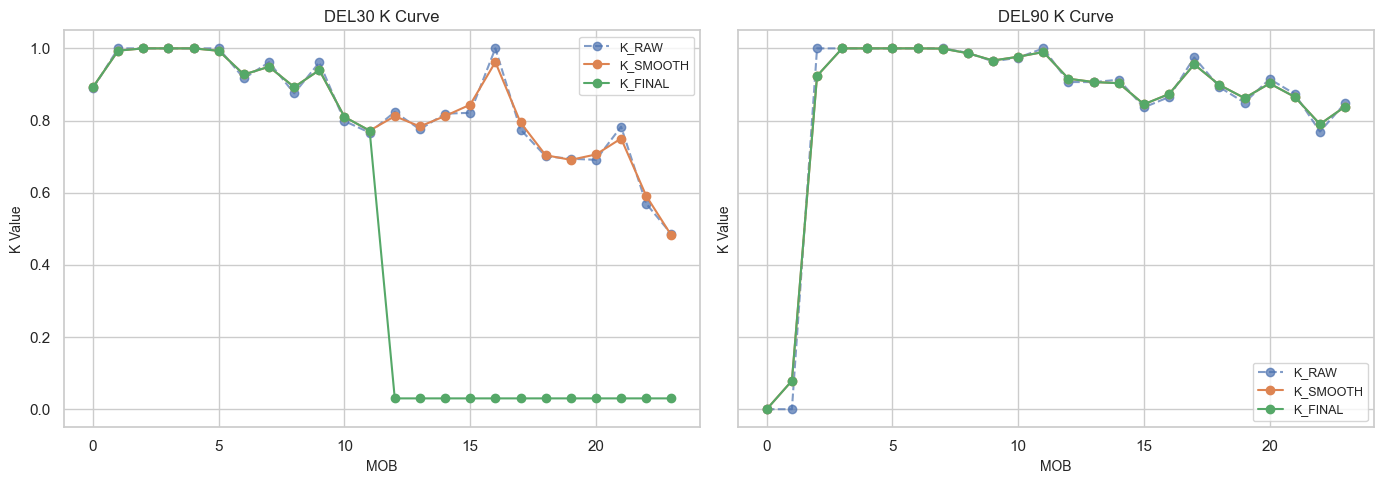

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, metric_name in zip(axes, ['DEL30', 'DEL90']):
    k_curve_df = results['metric_results'][metric_name]['fit_output']['k_curve_df'].copy()
    ax.plot(k_curve_df['MOB'], k_curve_df['K_RAW'], marker='o', linestyle='--', label='K_RAW', alpha=0.7)
    ax.plot(k_curve_df['MOB'], k_curve_df['K_SMOOTH'], marker='o', label='K_SMOOTH')
    ax.plot(k_curve_df['MOB'], k_curve_df['K_FINAL'], marker='o', label='K_FINAL')
    ax.set_title(f'{metric_name} K Curve')
    ax.set_xlabel('MOB')
    ax.set_ylabel('K Value')
    ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'k_curves_del30_del90.png', bbox_inches='tight')
plt.show()


## Actual vs Predicted Scatter

A well-calibrated model should place most observations close to the 45-degree line.


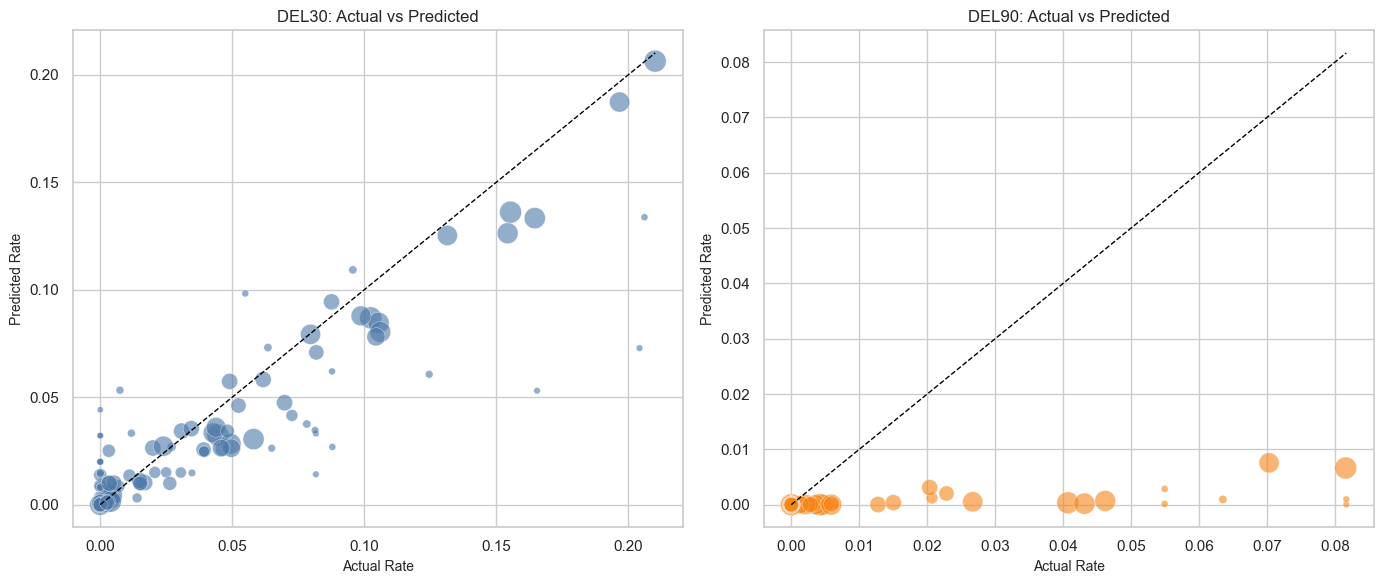

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)
for ax, metric_name in zip(axes, ['DEL30', 'DEL90']):
    compare_df = results['metric_results'][metric_name]['compare_df'].copy()
    if compare_df.empty:
        ax.set_title(f'{metric_name}: no holdout observations')
        continue
    sns.scatterplot(
        data=compare_df,
        x='ACTUAL_PCT',
        y='PRED_PCT',
        size='DISB_TOTAL',
        sizes=(20, 250),
        alpha=0.6,
        legend=False,
        ax=ax,
        color='#4C78A8' if metric_name == 'DEL30' else '#F58518',
    )
    lower = min(compare_df['ACTUAL_PCT'].min(), compare_df['PRED_PCT'].min())
    upper = max(compare_df['ACTUAL_PCT'].max(), compare_df['PRED_PCT'].max())
    ax.plot([lower, upper], [lower, upper], color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{metric_name}: Actual vs Predicted')
    ax.set_xlabel('Actual Rate')
    ax.set_ylabel('Predicted Rate')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'actual_vs_predicted_scatter.png', bbox_inches='tight')
plt.show()


## Error by MOB

This isolates where along the lifecycle the model performs well and where error concentrates.


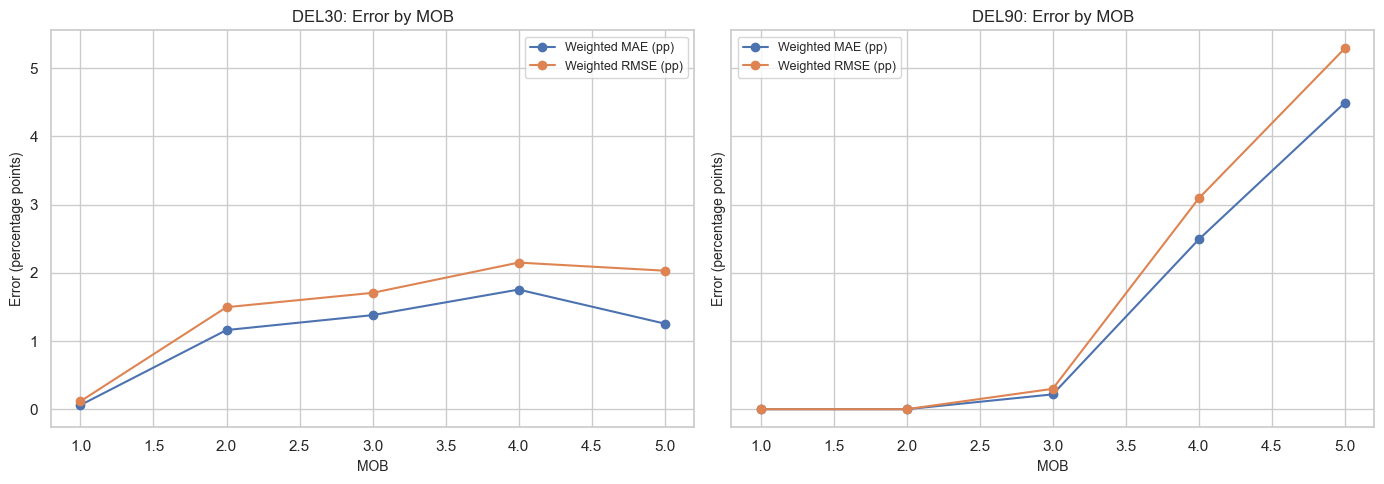

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, metric_name in zip(axes, ['DEL30', 'DEL90']):
    compare_df = results['metric_results'][metric_name]['compare_df'].copy()
    if compare_df.empty:
        ax.set_title(f'{metric_name}: no holdout observations')
        continue
    mob_error = weighted_group_error(compare_df, 'MOB').sort_values('MOB')
    ax.plot(mob_error['MOB'], mob_error['W_MAE'] * 100, marker='o', label='Weighted MAE (pp)')
    ax.plot(mob_error['MOB'], mob_error['W_RMSE'] * 100, marker='o', label='Weighted RMSE (pp)')
    ax.set_title(f'{metric_name}: Error by MOB')
    ax.set_xlabel('MOB')
    ax.set_ylabel('Error (percentage points)')
    ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'error_by_mob.png', bbox_inches='tight')
plt.show()


## Product-Vintage Error Heatmap

This helps identify whether misspecification is broad-based or concentrated in specific product / vintage pockets.


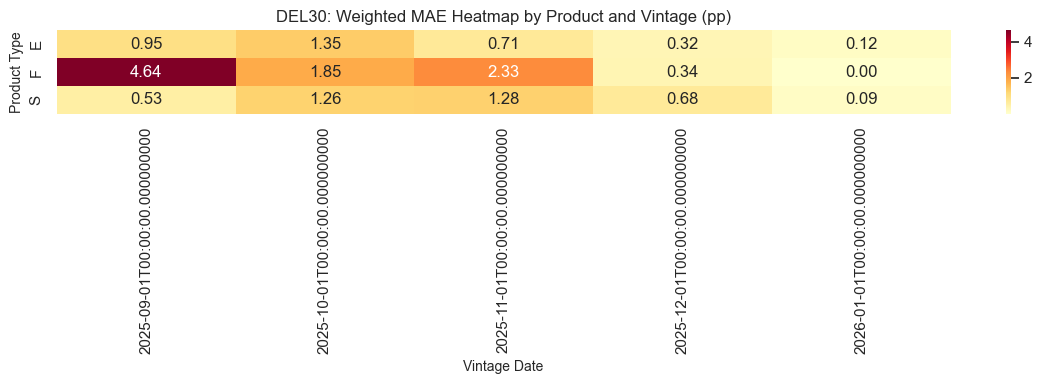

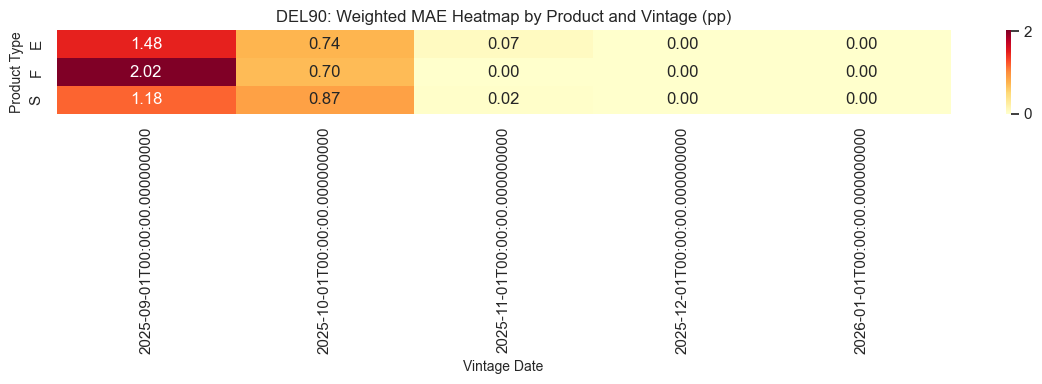

In [10]:
for metric_name in ['DEL30', 'DEL90']:
    compare_df = results['metric_results'][metric_name]['compare_df'].copy()
    if compare_df.empty:
        display(Markdown(f'**{metric_name}: no holdout observations for heatmap.**'))
        continue
    heatmap_df = (
        compare_df.groupby(['PRODUCT_TYPE', 'VINTAGE_DATE'])
        .apply(lambda g: np.average(g['ABS_ERROR'], weights=g['DISB_TOTAL']) if np.any(g['DISB_TOTAL'].fillna(0.0).values > 0) else g['ABS_ERROR'].mean())
        .rename('W_MAE')
        .reset_index()
    )
    pivot_df = heatmap_df.pivot(index='PRODUCT_TYPE', columns='VINTAGE_DATE', values='W_MAE') * 100
    plt.figure(figsize=(12, 4))
    sns.heatmap(pivot_df, annot=True, fmt='.2f', cmap='YlOrRd')
    plt.title(f'{metric_name}: Weighted MAE Heatmap by Product and Vintage (pp)')
    plt.xlabel('Vintage Date')
    plt.ylabel('Product Type')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{metric_name.lower()}_product_vintage_heatmap.png', bbox_inches='tight')
    plt.show()


## Path-Level Calibration Curves

These curves show whether cohorts with higher predicted delinquency also realize higher actual delinquency, and whether the model is over- or under-predicting across the score range.


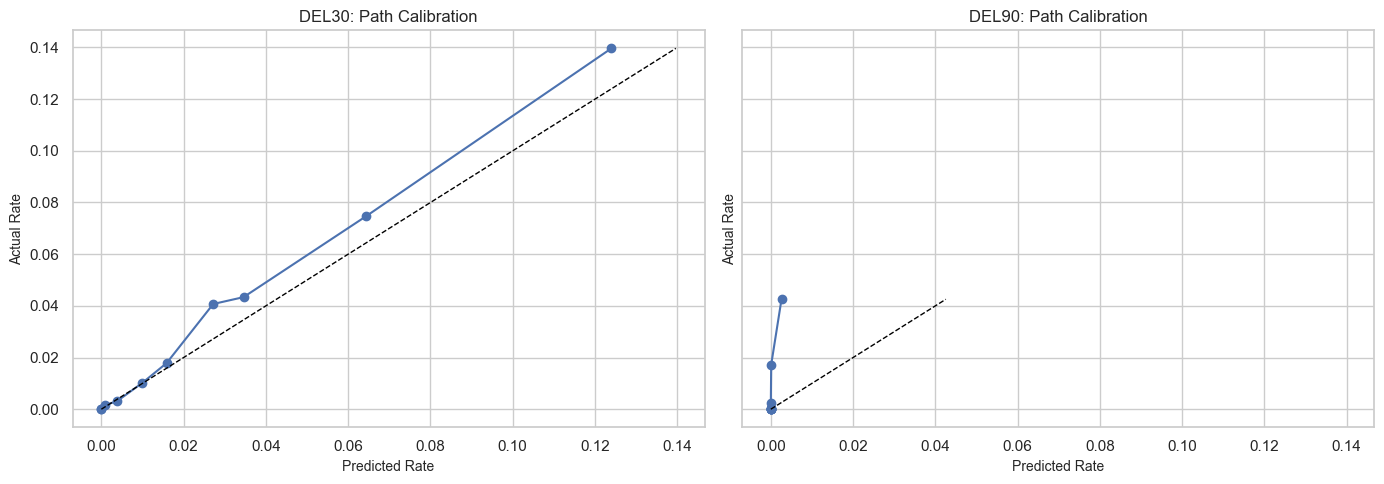

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, metric_name in zip(axes, ['DEL30', 'DEL90']):
    compare_df = results['metric_results'][metric_name]['compare_df'].copy()
    calib_df = build_calibration_bins(compare_df, 'PRED_PCT', 'ACTUAL_PCT', 'DISB_TOTAL', n_bins=10)
    if calib_df.empty:
        ax.set_title(f'{metric_name}: no calibration data')
        continue
    ax.plot(calib_df['PRED_MEAN'], calib_df['ACTUAL_MEAN'], marker='o')
    lower = min(calib_df[['PRED_MEAN', 'ACTUAL_MEAN']].min())
    upper = max(calib_df[['PRED_MEAN', 'ACTUAL_MEAN']].max())
    ax.plot([lower, upper], [lower, upper], linestyle='--', color='black', linewidth=1)
    ax.set_title(f'{metric_name}: Path Calibration')
    ax.set_xlabel('Predicted Rate')
    ax.set_ylabel('Actual Rate')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'path_calibration_curves.png', bbox_inches='tight')
plt.show()


## Loan-Level Brier Diagnostics

This section focuses on the exact binary outcome at target MOBs, which is the most relevant view if the model is used to assign delinquency probabilities to individual holdout loans.


In [12]:
for metric_name in ['DEL30', 'DEL90']:
    loan_df = results['metric_results'][metric_name]['loan_brier_df'].copy()
    if loan_df.empty:
        display(Markdown(f'**{metric_name}: no loan-level Brier detail for selected target MOBs.**'))
        continue
    display(Markdown(f'### {metric_name} loan-level summary'))
    display(results['metric_results'][metric_name]['loan_brier_summary_df'])

    target_mobs_present = sorted(loan_df['TARGET_MOB'].unique())
    fig, axes = plt.subplots(1, len(target_mobs_present), figsize=(6 * len(target_mobs_present), 4), squeeze=False)
    for ax, target_mob in zip(axes[0], target_mobs_present):
        subset = loan_df[loan_df['TARGET_MOB'] == target_mob].copy()
        calib_df = build_calibration_bins(subset, 'PRED_PROB', 'ACTUAL_EVENT', 'DISBURSAL_AMOUNT', n_bins=10)
        ax.plot(calib_df['PRED_MEAN'], calib_df['ACTUAL_MEAN'], marker='o')
        lower = min(calib_df[['PRED_MEAN', 'ACTUAL_MEAN']].min())
        upper = max(calib_df[['PRED_MEAN', 'ACTUAL_MEAN']].max())
        ax.plot([lower, upper], [lower, upper], linestyle='--', color='black', linewidth=1)
        ax.set_title(f'{metric_name}: Loan Calibration @ MOB {target_mob}')
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Observed Event Rate')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{metric_name.lower()}_loan_calibration.png', bbox_inches='tight')
    plt.show()


**DEL30: no loan-level Brier detail for selected target MOBs.**

**DEL90: no loan-level Brier detail for selected target MOBs.**

## Highest-Error Holdout Observations

Use these tables to inspect which holdout cohorts drive the worst misses.


In [13]:
for metric_name in ['DEL30', 'DEL90']:
    display(Markdown(f'### {metric_name} top errors'))
    err_df = top_error_rows(results['metric_results'][metric_name]['compare_df'], n=15).copy()
    for col in ['ACTUAL_PCT', 'PRED_PCT', 'ERROR', 'ABS_ERROR']:
        if col in err_df.columns:
            err_df[col] = err_df[col] * 100
    display(err_df)


### DEL30 top errors

,PRODUCT_TYPE,RISK_SCORE,VINTAGE_DATE,MOB,DISB_TOTAL,ACTUAL_PCT,PRED_PCT,ERROR,ABS_ERROR
79,F,M,2025-09-01,5,0.869139,20.429544,7.284331,-13.145213,13.145213
78,F,M,2025-09-01,4,0.869139,16.546051,5.301947,-11.244104,11.244104
64,F,L,2025-09-01,5,1.176084,20.615699,13.377044,-7.238655,7.238655
76,F,M,2025-09-01,2,0.869139,8.167236,1.414944,-6.752292,6.752292
71,F,L,2025-11-01,3,1.733970,12.462240,6.063526,-6.398714,6.398714
61,F,L,2025-09-01,2,1.176084,8.791209,2.687281,-6.103928,6.103928
77,F,M,2025-09-01,3,0.869139,8.167236,3.310318,-4.856918,4.856918
86,F,M,2025-11-01,3,1.549340,8.137442,3.461083,-4.676359,4.676359
83,F,M,2025-10-01,4,1.972956,0.747248,5.327048,4.579800,4.579800
49,F,H,2025-09-01,5,0.598812,0.000000,4.417566,4.417566,4.417566


### DEL90 top errors

,PRODUCT_TYPE,RISK_SCORE,VINTAGE_DATE,MOB,DISB_TOTAL,ACTUAL_PCT,PRED_PCT,ERROR,ABS_ERROR
78,F,M,2025-09-01,4,0.869139,8.167236,0.003775,-8.163461,8.163461
79,F,M,2025-09-01,5,0.869139,8.167236,0.099238,-8.067997,8.067997
19,E,L,2025-09-01,5,25.717052,8.158974,0.663255,-7.495719,7.495719
109,S,L,2025-09-01,5,21.331062,7.031306,0.755986,-6.275320,6.275320
68,F,L,2025-10-01,4,2.193849,6.350941,0.094376,-6.256565,6.256565
63,F,L,2025-09-01,4,1.176084,5.494506,0.012995,-5.481511,5.481511
64,F,L,2025-09-01,5,1.176084,5.494506,0.283555,-5.210950,5.210950
113,S,L,2025-10-01,4,23.068113,4.619719,0.067890,-4.551829,4.551829
23,E,L,2025-10-01,4,23.734936,4.313750,0.018720,-4.295029,4.295029
18,E,L,2025-09-01,4,25.717052,4.069093,0.034367,-4.034727,4.034727


## Holdout Trajectories for Largest Cohorts

This gives a visual sense of whether the model tracks the delinquency path well over time, not just on summary metrics.


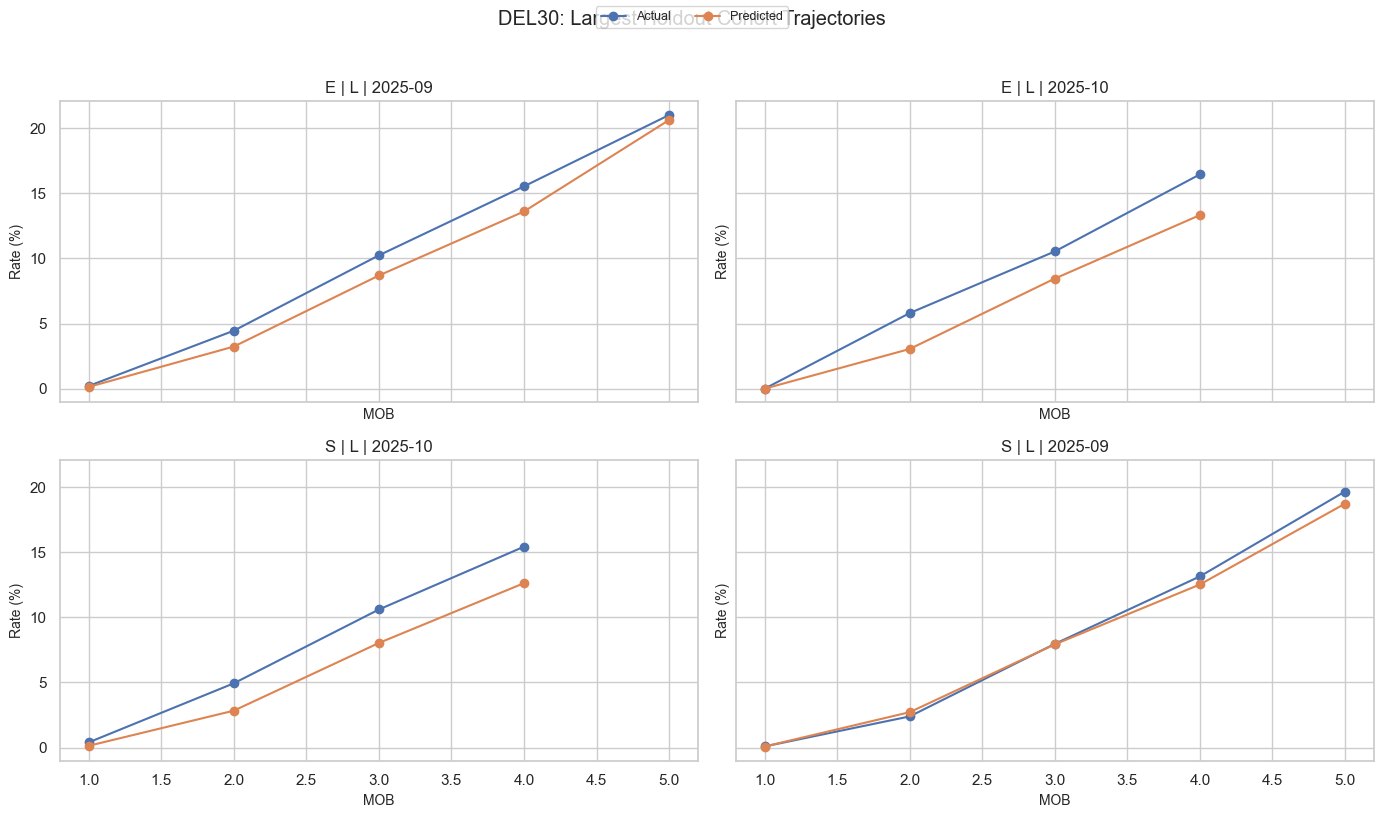

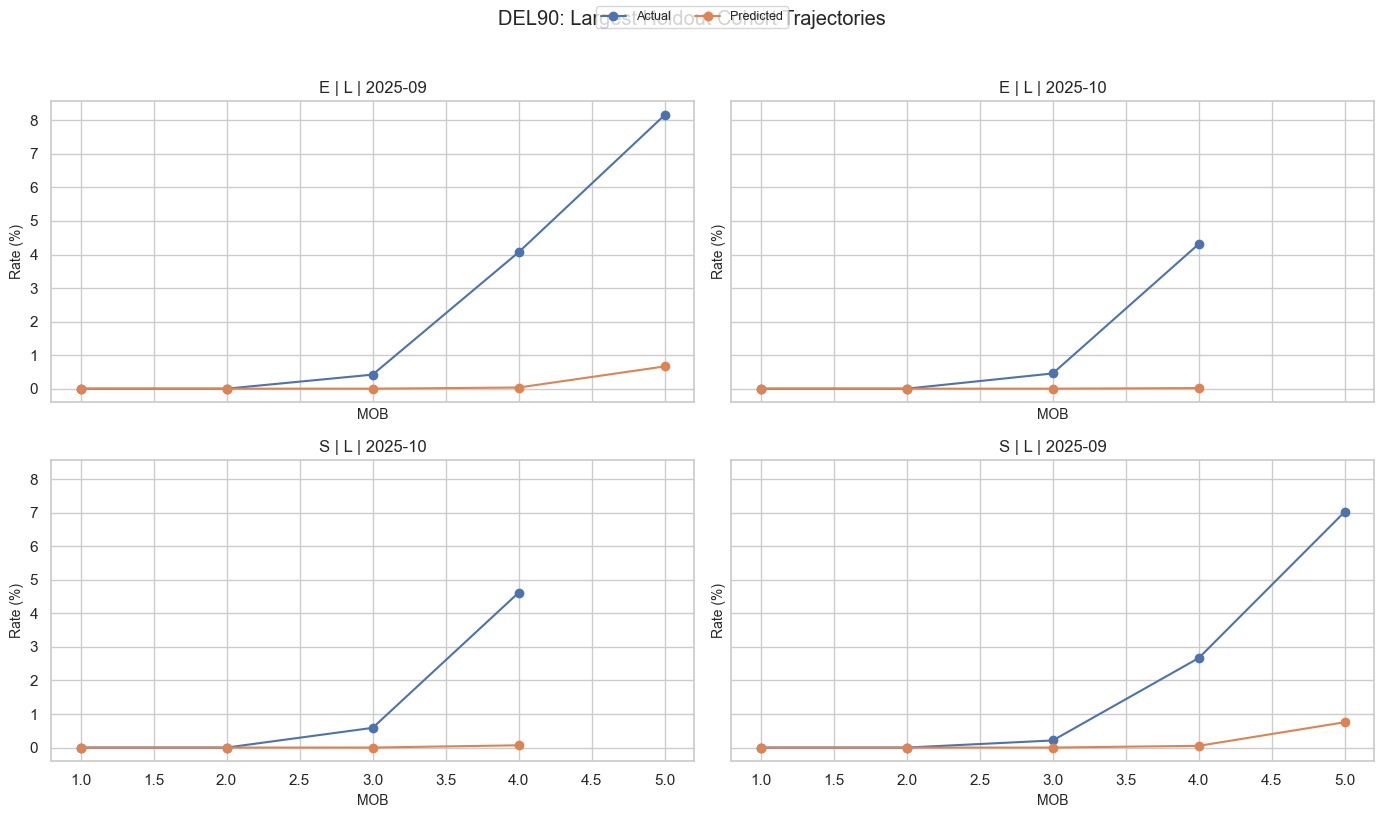

In [14]:
for metric_name in ['DEL30', 'DEL90']:
    compare_df = results['metric_results'][metric_name]['compare_df'].copy()
    if compare_df.empty:
        display(Markdown(f'**{metric_name}: no trajectories to plot.**'))
        continue
    cohort_sizes = (
        compare_df.groupby(['PRODUCT_TYPE', 'RISK_SCORE', 'VINTAGE_DATE'], as_index=False)['DISB_TOTAL']
        .max()
        .sort_values('DISB_TOTAL', ascending=False)
        .head(4)
    )
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
    for ax, (_, cohort_row) in zip(axes.flatten(), cohort_sizes.iterrows()):
        mask = (
            (compare_df['PRODUCT_TYPE'] == cohort_row['PRODUCT_TYPE']) &
            (compare_df['RISK_SCORE'] == cohort_row['RISK_SCORE']) &
            (compare_df['VINTAGE_DATE'] == cohort_row['VINTAGE_DATE'])
        )
        subset = compare_df[mask].sort_values('MOB')
        ax.plot(subset['MOB'], subset['ACTUAL_PCT'] * 100, marker='o', label='Actual')
        ax.plot(subset['MOB'], subset['PRED_PCT'] * 100, marker='o', label='Predicted')
        ax.set_title(f"{cohort_row['PRODUCT_TYPE']} | {cohort_row['RISK_SCORE']} | {pd.Timestamp(cohort_row['VINTAGE_DATE']).strftime('%Y-%m')}")
        ax.set_xlabel('MOB')
        ax.set_ylabel('Rate (%)')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)
    fig.suptitle(f'{metric_name}: Largest Holdout Cohort Trajectories', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{metric_name.lower()}_largest_cohort_trajectories.png', bbox_inches='tight')
    plt.show()


## Automated Reading Notes

This cell generates a compact written readout from the backtest results.


In [15]:
notes = []
for metric_name in ['DEL30', 'DEL90']:
    row = path_summary_df[path_summary_df['METRIC'] == metric_name].iloc[0]
    corr_text = f"{row['CORR']:.3f}" if pd.notna(row['CORR']) else 'nan'
    notes.append(
        f"- **{metric_name} path metrics**: weighted MAE = {row['WEIGHTED_MAE'] * 100:.2f} pp, weighted RMSE = {row['WEIGHTED_RMSE'] * 100:.2f} pp, bias = {row['BIAS'] * 100:.2f} pp, correlation = {corr_text}."
    )
    metric_compare = results['metric_results'][metric_name]['compare_df']
    if not metric_compare.empty:
        top_mob = weighted_group_error(metric_compare, 'MOB').sort_values('W_MAE', ascending=False).iloc[0]
        notes.append(
            f"- **{metric_name} highest-error MOB**: MOB {int(top_mob['MOB'])} with weighted MAE {top_mob['W_MAE'] * 100:.2f} pp."
        )

if not loan_brier_summary_df.empty:
    for _, row in loan_brier_summary_df.iterrows():
        notes.append(
            f"- **{row['METRIC']} loan-level @ MOB {int(row['TARGET_MOB'])}**: Brier = {row['BRIER'] * 100:.2f} pct^2, weighted Brier = {row['WEIGHTED_BRIER'] * 100:.2f} pct^2, predicted rate = {row['PRED_RATE'] * 100:.2f}%, actual rate = {row['ACTUAL_RATE'] * 100:.2f}%."
        )

summary_md = '## Backtest Readout\n' + '\n'.join(notes) + f"\n\nArtifacts saved to: `{OUTPUT_DIR}`"
display(Markdown(summary_md))

## Backtest Readout
- **DEL30 path metrics**: weighted MAE = 0.95 pp, weighted RMSE = 1.47 pp, bias = -0.59 pp, correlation = 0.892.
- **DEL30 highest-error MOB**: MOB 4 with weighted MAE 1.75 pp.
- **DEL90 path metrics**: weighted MAE = 0.73 pp, weighted RMSE = 1.84 pp, bias = -0.56 pp, correlation = 0.654.
- **DEL90 highest-error MOB**: MOB 5 with weighted MAE 4.49 pp.

Artifacts saved to: `D:\backup_ổ c\RR_model_1911_Projection\notebooks\outputs\oot_backtest_ntb`

## Mature Rolling OOT for Business Horizons

The latest OOT section above is useful for recent short-horizon behavior, but it cannot validate `MOB12` / `MOB24` if the newest vintages are still too young.

This section builds **mature rolling holdout windows**:
- train on older vintages only,
- hold out a later vintage window,
- require that holdout vintages are already mature enough to observe actual outcomes at the requested target MOB.

This is the right setup for judging whether the model is usable for business reporting horizons such as `MOB12` and `MOB24`.


In [16]:
MATURE_OUTPUT_DIR = OUTPUT_DIR / 'mature_rolling'
MATURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('MATURE_TARGET_MOBS =', MATURE_TARGET_MOBS)
print('MATURE_HOLDOUT_MONTHS =', MATURE_HOLDOUT_MONTHS)
print('MAX_MATURE_WINDOWS_PER_TARGET =', MAX_MATURE_WINDOWS_PER_TARGET)
MATURE_OUTPUT_DIR


MATURE_TARGET_MOBS = [12, 24]
MATURE_HOLDOUT_MONTHS = 6
MAX_MATURE_WINDOWS_PER_TARGET = 2


WindowsPath('D:/backup_ổ c/RR_model_1911_Projection/notebooks/outputs/oot_backtest_ntb/mature_rolling')

In [17]:
mature_results = run_rolling_mature_oot_backtest(
    df_raw,
    mature_target_mobs=MATURE_TARGET_MOBS,
    holdout_months=MATURE_HOLDOUT_MONTHS,
    min_train_vintages=MIN_TRAIN_VINTAGES,
    max_windows_per_target=MAX_MATURE_WINDOWS_PER_TARGET,
    anchor_mob=ANCHOR_MOB,
    product_filter=PRODUCT_FILTER,
    risk_filter=RISK_FILTER,
    fit_params=FIT_PARAMS,
    settings_overrides=SETTINGS_OVERRIDES,
)

save_mature_result_tables(mature_results, MATURE_OUTPUT_DIR)

windows_catalog_df = mature_results['windows_catalog_df'].copy()
mature_path_summary_df = mature_results['mature_path_summary_df'].copy()
mature_loan_brier_summary_df = mature_results['mature_loan_brier_summary_df'].copy()
path_summary_by_window_df = mature_results['path_summary_by_window_df'].copy()
loan_brier_summary_by_window_df = mature_results['loan_brier_summary_by_window_df'].copy()

windows_catalog_df


⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=E, score=H)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=E, score=L)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=E, score=M)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=E, score=nan)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=F, score=H)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=F, score=L)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=F, score=M)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=F, score=nan)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOUT']
⚙️ Built parent fallback for (product=S, score=H)
⚠️ Có 2 hàng có tổng weight = 0: ['PREPAY', 'SOLDOU

,TARGET_MOB,WINDOW_ID,START_VINTAGE,END_VINTAGE,N_HOLDOUT_VINTAGES,N_TRAIN_VINTAGES,MIN_HOLDOUT_MAX_MOB
0,12,MOB12_202403_202408,2024-03-01,2024-08-01,6,14,18
1,12,MOB12_202409_202502,2024-09-01,2025-02-01,6,20,12


## Mature Window Coverage

These are the actual holdout windows used for `MOB12` / `MOB24` evaluation.


,TARGET_MOB,WINDOW_ID,START_VINTAGE,END_VINTAGE,N_HOLDOUT_VINTAGES,N_TRAIN_VINTAGES,MIN_HOLDOUT_MAX_MOB
0,12,MOB12_202403_202408,2024-03-01,2024-08-01,6,14,18
1,12,MOB12_202409_202502,2024-09-01,2025-02-01,6,20,12


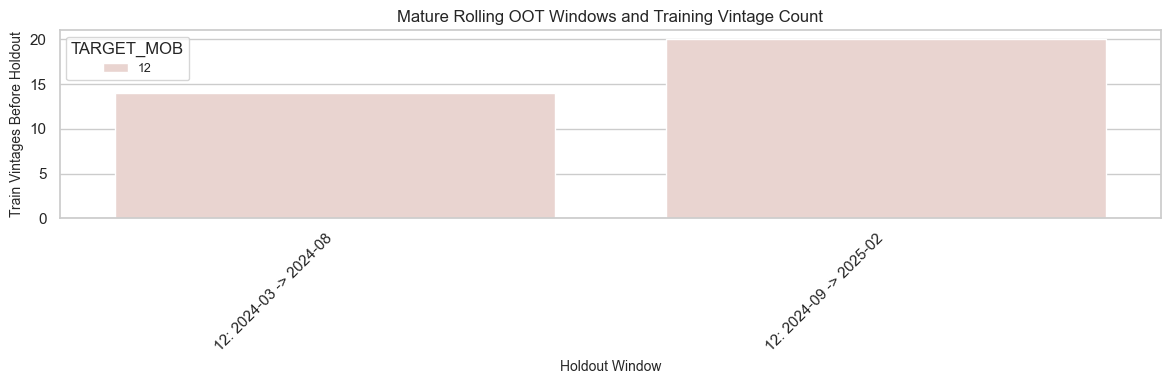

In [18]:
display(windows_catalog_df)

if not windows_catalog_df.empty:
    timeline_df = windows_catalog_df.copy()
    timeline_df['WINDOW_LABEL'] = timeline_df.apply(
        lambda row: f"{int(row['TARGET_MOB'])}: {pd.Timestamp(row['START_VINTAGE']).strftime('%Y-%m')} -> {pd.Timestamp(row['END_VINTAGE']).strftime('%Y-%m')}",
        axis=1,
    )
    plt.figure(figsize=(12, 4))
    sns.barplot(data=timeline_df, x='WINDOW_LABEL', y='N_TRAIN_VINTAGES', hue='TARGET_MOB', dodge=False)
    plt.xticks(rotation=45, ha='right')
    plt.title('Mature Rolling OOT Windows and Training Vintage Count')
    plt.xlabel('Holdout Window')
    plt.ylabel('Train Vintages Before Holdout')
    plt.tight_layout()
    plt.savefig(MATURE_OUTPUT_DIR / 'mature_window_coverage.png', bbox_inches='tight')
    plt.show()
else:
    display(Markdown('**No mature holdout windows found for the selected target MOBs.**'))


## Mature OOT Summary

These are the aggregated mature-window metrics. This is the key table to judge whether the model is good enough at `MOB12` / `MOB24`.


In [19]:
mature_path_display = mature_path_summary_df.copy()
for col in ['MAE', 'RMSE', 'BRIER', 'WEIGHTED_MAE', 'WEIGHTED_RMSE', 'WEIGHTED_BRIER', 'BIAS']:
    if col in mature_path_display.columns:
        mature_path_display[col] = mature_path_display[col] * 100
mature_path_display = mature_path_display.rename(columns={
    'MAE': 'MAE_PP',
    'RMSE': 'RMSE_PP',
    'BRIER': 'BRIER_PP2',
    'WEIGHTED_MAE': 'W_MAE_PP',
    'WEIGHTED_RMSE': 'W_RMSE_PP',
    'WEIGHTED_BRIER': 'W_BRIER_PP2',
    'BIAS': 'BIAS_PP',
})
display(mature_path_display)

if not mature_loan_brier_summary_df.empty:
    mature_loan_display = mature_loan_brier_summary_df.copy()
    for col in ['ACTUAL_RATE', 'PRED_RATE', 'BRIER', 'WEIGHTED_BRIER', 'MAE', 'WEIGHTED_MAE']:
        mature_loan_display[col] = mature_loan_display[col] * 100
    mature_loan_display = mature_loan_display.rename(columns={
        'ACTUAL_RATE': 'ACTUAL_RATE_PCT',
        'PRED_RATE': 'PRED_RATE_PCT',
        'BRIER': 'BRIER_PCT2',
        'WEIGHTED_BRIER': 'W_BRIER_PCT2',
        'MAE': 'MAE_PCT',
        'WEIGHTED_MAE': 'W_MAE_PCT',
    })
    display(mature_loan_display)
else:
    display(Markdown('**No mature loan-level Brier results were produced.**'))


,N_OBS,N_COHORTS,MAE_PP,RMSE_PP,BRIER_PP2,W_MAE_PP,W_RMSE_PP,W_BRIER_PP2,BIAS_PP,CORR,METRIC,TARGET_MOB_WINDOW,N_WINDOWS
0,1296,108,3.647509,5.845822,0.341736,4.536836,6.892712,0.475095,-1.660400,0.855149,DEL30,12,2
1,1296,108,3.711450,6.341722,0.402174,4.580517,6.955203,0.483749,-3.487872,0.838125,DEL90,12,2
2,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEL30,24,0
3,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEL90,24,0


,N_LOANS,ACTUAL_RATE_PCT,PRED_RATE_PCT,BRIER_PCT2,W_BRIER_PCT2,MAE_PCT,W_MAE_PCT,METRIC,TARGET_MOB_WINDOW,N_WINDOWS
0,60598,30.685831,22.369473,21.293209,21.416998,37.846099,37.947749,DEL30,12,2
1,60598,24.726889,16.808916,18.558964,18.690337,32.065726,32.137855,DEL90,12,2


## Mature OOT Metric Charts


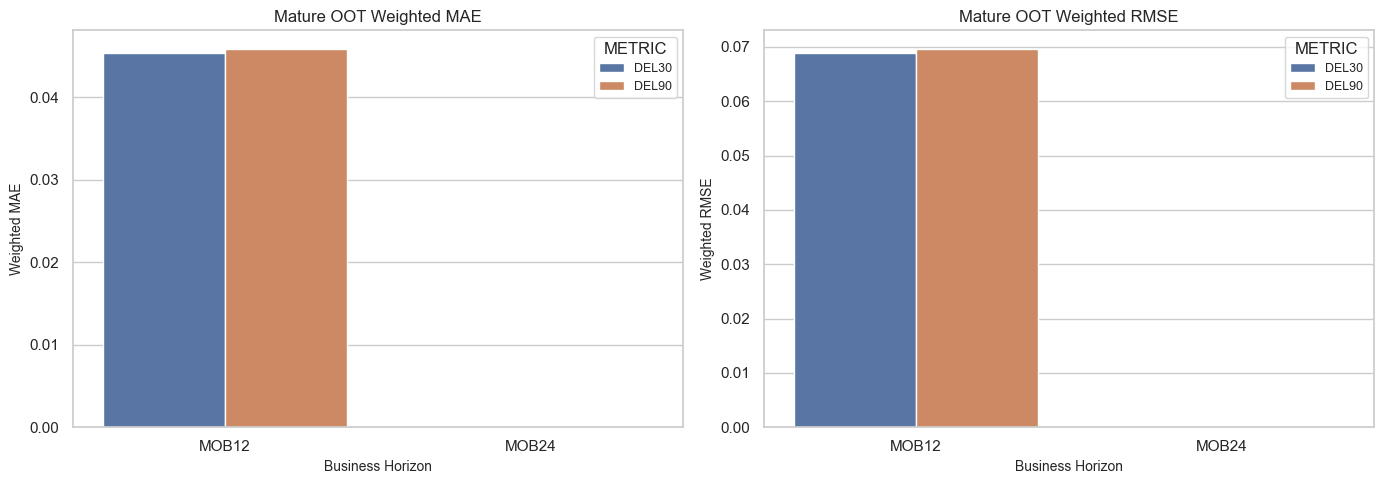

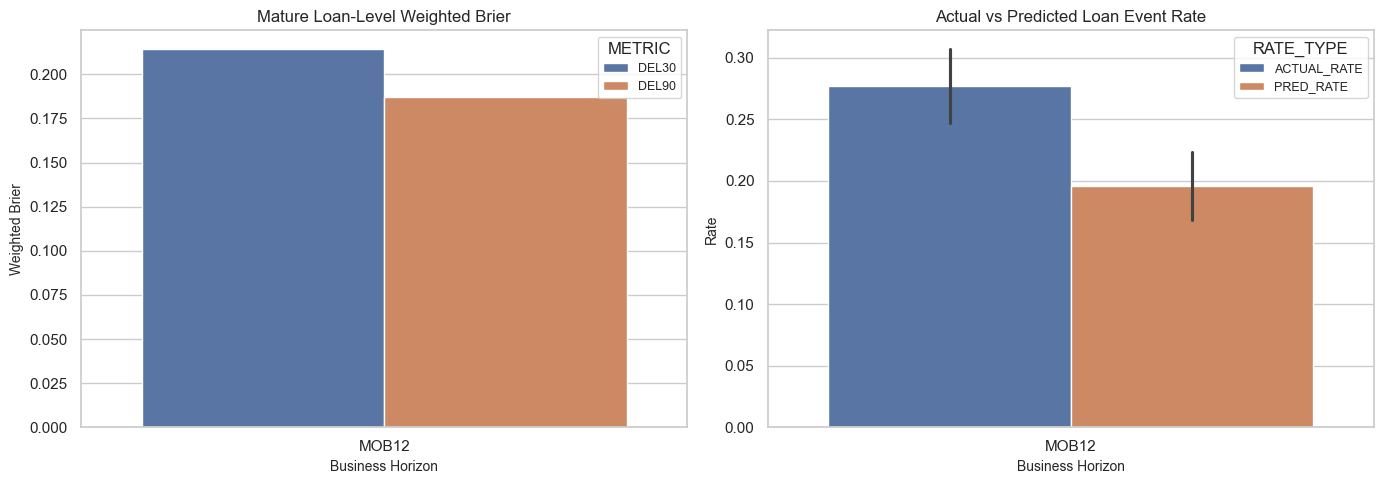

In [20]:
if not mature_path_summary_df.empty:
    chart_df = mature_path_summary_df.copy()
    chart_df['TARGET_LABEL'] = chart_df['TARGET_MOB_WINDOW'].astype(int).astype(str).radd('MOB')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    sns.barplot(data=chart_df, x='TARGET_LABEL', y='WEIGHTED_MAE', hue='METRIC', ax=axes[0])
    axes[0].set_title('Mature OOT Weighted MAE')
    axes[0].set_xlabel('Business Horizon')
    axes[0].set_ylabel('Weighted MAE')

    sns.barplot(data=chart_df, x='TARGET_LABEL', y='WEIGHTED_RMSE', hue='METRIC', ax=axes[1])
    axes[1].set_title('Mature OOT Weighted RMSE')
    axes[1].set_xlabel('Business Horizon')
    axes[1].set_ylabel('Weighted RMSE')

    plt.tight_layout()
    plt.savefig(MATURE_OUTPUT_DIR / 'mature_weighted_error_summary.png', bbox_inches='tight')
    plt.show()

if not mature_loan_brier_summary_df.empty:
    loan_chart_df = mature_loan_brier_summary_df.copy()
    loan_chart_df['TARGET_LABEL'] = loan_chart_df['TARGET_MOB_WINDOW'].astype(int).astype(str).radd('MOB')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    sns.barplot(data=loan_chart_df, x='TARGET_LABEL', y='WEIGHTED_BRIER', hue='METRIC', ax=axes[0])
    axes[0].set_title('Mature Loan-Level Weighted Brier')
    axes[0].set_xlabel('Business Horizon')
    axes[0].set_ylabel('Weighted Brier')

    rate_df = pd.melt(
        loan_chart_df,
        id_vars=['METRIC', 'TARGET_LABEL'],
        value_vars=['ACTUAL_RATE', 'PRED_RATE'],
        var_name='RATE_TYPE',
        value_name='RATE_VALUE',
    )
    sns.barplot(data=rate_df, x='TARGET_LABEL', y='RATE_VALUE', hue='RATE_TYPE', ax=axes[1])
    axes[1].set_title('Actual vs Predicted Loan Event Rate')
    axes[1].set_xlabel('Business Horizon')
    axes[1].set_ylabel('Rate')

    plt.tight_layout()
    plt.savefig(MATURE_OUTPUT_DIR / 'mature_loan_brier_summary.png', bbox_inches='tight')
    plt.show()


## Mature OOT by Window

This view shows whether performance is stable across different historical holdout windows or only looks good in one period.


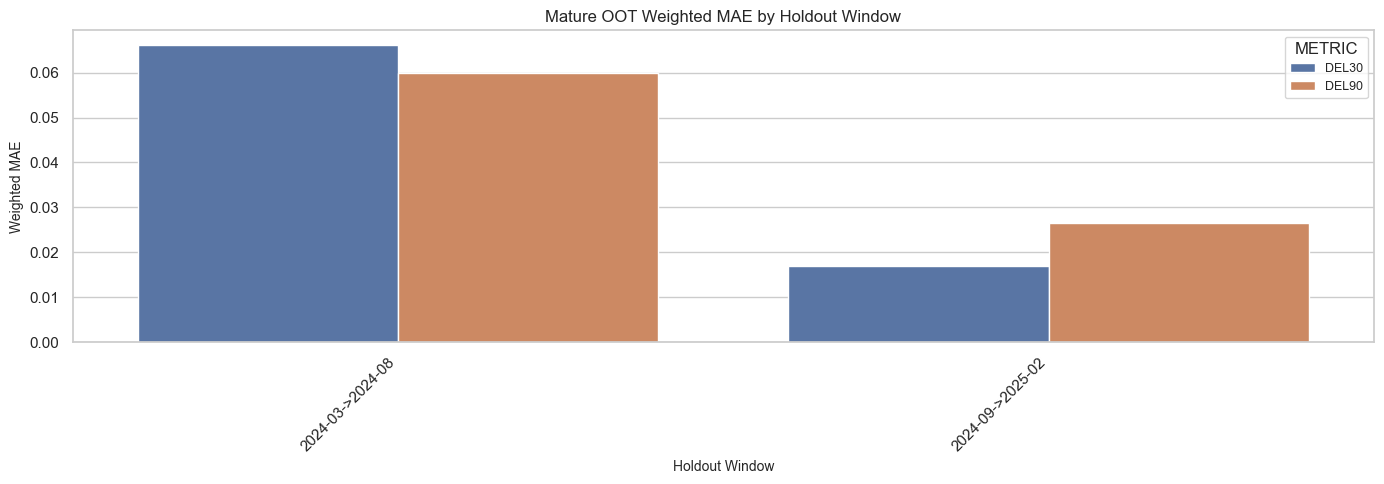

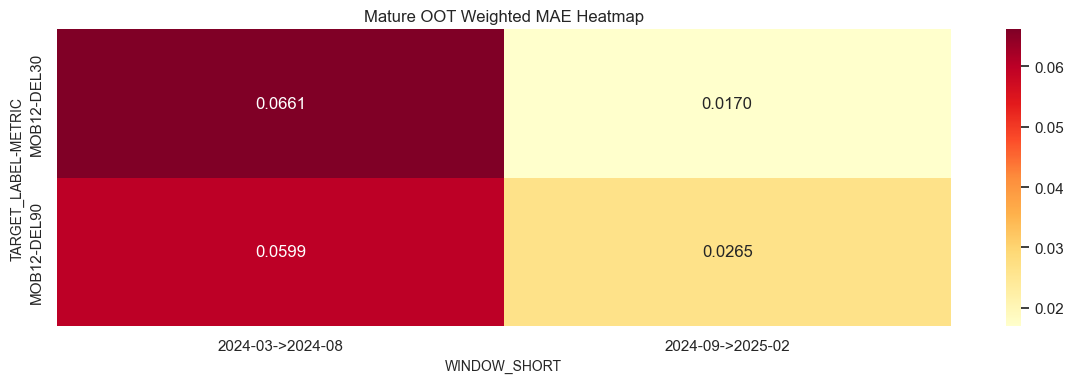

In [21]:
if not path_summary_by_window_df.empty:
    path_window_chart = path_summary_by_window_df.copy()
    path_window_chart['WINDOW_SHORT'] = path_window_chart.apply(
        lambda row: f"{pd.Timestamp(row['WINDOW_START_VINTAGE']).strftime('%Y-%m')}->{pd.Timestamp(row['WINDOW_END_VINTAGE']).strftime('%Y-%m')}",
        axis=1,
    )
    path_window_chart['TARGET_LABEL'] = path_window_chart['TARGET_MOB_WINDOW'].astype(int).astype(str).radd('MOB')

    plt.figure(figsize=(14, 5))
    sns.barplot(data=path_window_chart, x='WINDOW_SHORT', y='WEIGHTED_MAE', hue='METRIC')
    plt.xticks(rotation=45, ha='right')
    plt.title('Mature OOT Weighted MAE by Holdout Window')
    plt.xlabel('Holdout Window')
    plt.ylabel('Weighted MAE')
    plt.tight_layout()
    plt.savefig(MATURE_OUTPUT_DIR / 'mature_weighted_mae_by_window.png', bbox_inches='tight')
    plt.show()

    heatmap_df = path_window_chart.pivot_table(
        index=['TARGET_LABEL', 'METRIC'],
        columns='WINDOW_SHORT',
        values='WEIGHTED_MAE',
        aggfunc='mean',
    )
    plt.figure(figsize=(12, 4))
    sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='YlOrRd')
    plt.title('Mature OOT Weighted MAE Heatmap')
    plt.tight_layout()
    plt.savefig(MATURE_OUTPUT_DIR / 'mature_weighted_mae_heatmap.png', bbox_inches='tight')
    plt.show()


## Mature OOT Highest-Error Cohorts


In [22]:
if not mature_results['mature_compare_df'].empty:
    for target_mob in sorted(mature_results['mature_compare_df']['TARGET_MOB_WINDOW'].unique()):
        for metric_name in ['DEL30', 'DEL90']:
            display(Markdown(f'### {metric_name} | Mature OOT @ MOB {int(target_mob)}'))
            subset = mature_results['mature_compare_df'][
                (mature_results['mature_compare_df']['TARGET_MOB_WINDOW'] == target_mob) &
                (mature_results['mature_compare_df']['METRIC'] == metric_name) &
                (mature_results['mature_compare_df']['MOB'] == target_mob)
            ].copy()
            err_df = top_error_rows(subset, n=12)
            for col in ['ACTUAL_PCT', 'PRED_PCT', 'ERROR', 'ABS_ERROR']:
                if col in err_df.columns:
                    err_df[col] = err_df[col] * 100
            display(err_df)


### DEL30 | Mature OOT @ MOB 12

,PRODUCT_TYPE,RISK_SCORE,VINTAGE_DATE,MOB,DISB_TOTAL,ACTUAL_PCT,PRED_PCT,ERROR,ABS_ERROR
143,E,L,2024-08-01,12,39.970917,37.249474,16.765502,-20.483971,20.483971
1655,F,L,2025-02-01,12,1.214856,46.290503,27.169995,-19.120509,19.120509
107,E,L,2024-05-01,12,10.674705,36.049351,17.030190,-19.019161,19.019161
131,E,L,2024-07-01,12,31.523046,35.238385,16.655021,-18.583364,18.583364
539,S,L,2024-05-01,12,75.193718,41.109088,24.311479,-16.797609,16.797609
527,S,L,2024-04-01,12,73.323303,41.093328,24.330346,-16.762981,16.762981
515,S,L,2024-03-01,12,74.794106,40.384341,24.208461,-16.175880,16.175880
83,E,L,2024-03-01,12,11.458011,32.878258,17.213661,-15.664596,15.664596
551,S,L,2024-06-01,12,72.511398,39.294015,24.155585,-15.138429,15.138429
299,F,L,2024-03-01,12,1.106079,38.948584,23.970266,-14.978319,14.978319


### DEL90 | Mature OOT @ MOB 12

,PRODUCT_TYPE,RISK_SCORE,VINTAGE_DATE,MOB,DISB_TOTAL,ACTUAL_PCT,PRED_PCT,ERROR,ABS_ERROR
2303,F,L,2025-02-01,12,1.214856,42.045311,16.965419,-25.079891,25.079891
791,E,L,2024-08-01,12,39.970917,32.730807,11.728542,-21.002265,21.002265
755,E,L,2024-05-01,12,10.674705,32.780847,12.007719,-20.773127,20.773127
947,F,L,2024-03-01,12,1.106079,35.244703,15.937353,-19.307351,19.307351
779,E,L,2024-07-01,12,31.523046,30.149896,11.669940,-18.479956,18.479956
731,E,L,2024-03-01,12,11.458011,29.841917,12.269331,-17.572586,17.572586
2375,F,M,2025-02-01,12,0.407106,28.184953,11.153028,-17.031924,17.031924
1187,S,L,2024-05-01,12,75.193718,35.839658,20.167985,-15.671673,15.671673
1175,S,L,2024-04-01,12,73.323303,35.854424,20.182827,-15.671597,15.671597
767,E,L,2024-06-01,12,13.709242,27.618438,11.959816,-15.658622,15.658622


## Mature Backtest Readout


In [23]:
mature_notes = []
if not mature_path_summary_df.empty:
    for _, row in mature_path_summary_df.iterrows():
        corr_text = f"{row['CORR']:.3f}" if pd.notna(row['CORR']) else 'nan'
        mature_notes.append(
            f"- **{row['METRIC']} @ MOB {int(row['TARGET_MOB_WINDOW'])}**: weighted MAE = {row['WEIGHTED_MAE'] * 100:.2f} pp, weighted RMSE = {row['WEIGHTED_RMSE'] * 100:.2f} pp, bias = {row['BIAS'] * 100:.2f} pp, correlation = {corr_text}, windows = {int(row['N_WINDOWS'])}."
        )
if not mature_loan_brier_summary_df.empty:
    for _, row in mature_loan_brier_summary_df.iterrows():
        mature_notes.append(
            f"- **{row['METRIC']} loan-level @ MOB {int(row['TARGET_MOB_WINDOW'])}**: weighted Brier = {row['WEIGHTED_BRIER'] * 100:.2f} pct^2, weighted MAE = {row['WEIGHTED_MAE'] * 100:.2f} pct, predicted rate = {row['PRED_RATE'] * 100:.2f}%, actual rate = {row['ACTUAL_RATE'] * 100:.2f}%."
        )

if mature_notes:
    mature_summary_md = '## Mature Rolling OOT Readout\n' + '\n'.join(mature_notes) + f"\n\nArtifacts saved to: `{MATURE_OUTPUT_DIR}`"
else:
    mature_summary_md = '## Mature Rolling OOT Readout\nNo mature windows were available for the chosen settings.'
display(Markdown(mature_summary_md))


## Mature Rolling OOT Readout
- **DEL30 @ MOB 12**: weighted MAE = 4.54 pp, weighted RMSE = 6.89 pp, bias = -1.66 pp, correlation = 0.855, windows = 2.
- **DEL90 @ MOB 12**: weighted MAE = 4.58 pp, weighted RMSE = 6.96 pp, bias = -3.49 pp, correlation = 0.838, windows = 2.
- **DEL30 @ MOB 24**: weighted MAE = nan pp, weighted RMSE = nan pp, bias = nan pp, correlation = nan, windows = 0.
- **DEL90 @ MOB 24**: weighted MAE = nan pp, weighted RMSE = nan pp, bias = nan pp, correlation = nan, windows = 0.
- **DEL30 loan-level @ MOB 12**: weighted Brier = 21.42 pct^2, weighted MAE = 37.95 pct, predicted rate = 22.37%, actual rate = 30.69%.
- **DEL90 loan-level @ MOB 12**: weighted Brier = 18.69 pct^2, weighted MAE = 32.14 pct, predicted rate = 16.81%, actual rate = 24.73%.

Artifacts saved to: `D:\backup_ổ c\RR_model_1911_Projection\notebooks\outputs\oot_backtest_ntb\mature_rolling`

## ROLL_WINDOW-Aware Interpretation

Because the transition engine uses a finite `ROLL_WINDOW`, very old mature windows may be less representative of how the current model behaves now.

This section treats the **latest mature window** as the primary view for current model relevance, and keeps the full rolling history as secondary context.


In [ ]:
latest_window_path_df = pd.DataFrame()
latest_window_loan_df = pd.DataFrame()
recency_weighted_summary_df = pd.DataFrame()

if not path_summary_by_window_df.empty:
    latest_window_rows = []
    recency_rows = []
    latest_end = pd.to_datetime(path_summary_by_window_df['WINDOW_END_VINTAGE']).max()
    latest_period = latest_end.to_period('M')

    for target_mob in sorted(path_summary_by_window_df['TARGET_MOB_WINDOW'].dropna().unique()):
        for metric_name in sorted(path_summary_by_window_df['METRIC'].dropna().unique()):
            subset = path_summary_by_window_df[
                (path_summary_by_window_df['TARGET_MOB_WINDOW'] == target_mob) &
                (path_summary_by_window_df['METRIC'] == metric_name)
            ].copy()
            if subset.empty:
                continue

            latest_row = subset.sort_values('WINDOW_END_VINTAGE').iloc[-1].to_dict()
            latest_window_rows.append(latest_row)

            detail_subset = mature_results['mature_compare_df'][
                (mature_results['mature_compare_df']['TARGET_MOB_WINDOW'] == target_mob) &
                (mature_results['mature_compare_df']['METRIC'] == metric_name) &
                (mature_results['mature_compare_df']['MOB'] == target_mob)
            ].copy()
            if not detail_subset.empty:
                detail_subset['months_from_latest'] = detail_subset['WINDOW_END_VINTAGE'].apply(
                    lambda ts: latest_period.ordinal - pd.Timestamp(ts).to_period('M').ordinal
                )
                lam = 0.5 ** (1 / SETTINGS_OVERRIDES['roll_window']) if SETTINGS_OVERRIDES.get('roll_window') else 0.5 ** (1 / 20)
                detail_subset['RECENCY_WEIGHT'] = (lam ** detail_subset['months_from_latest']) * detail_subset['DISB_TOTAL']
                recency_rows.append({
                    'TARGET_MOB_WINDOW': target_mob,
                    'METRIC': metric_name,
                    'LATEST_WINDOW_END': latest_end,
                    'RECENCY_WEIGHTED_MAE': np.average(detail_subset['ABS_ERROR'], weights=detail_subset['RECENCY_WEIGHT']),
                    'RECENCY_WEIGHTED_RMSE': np.sqrt(np.average(detail_subset['SQ_ERROR'], weights=detail_subset['RECENCY_WEIGHT'])),
                    'RECENCY_WEIGHTED_BIAS': np.average(detail_subset['ERROR'], weights=detail_subset['RECENCY_WEIGHT']),
                    'LATEST_WINDOW_ONLY_MAE': latest_row['WEIGHTED_MAE'],
                    'LATEST_WINDOW_ONLY_RMSE': latest_row['WEIGHTED_RMSE'],
                    'LATEST_WINDOW_ONLY_BIAS': latest_row['BIAS'],
                })

    latest_window_path_df = pd.DataFrame(latest_window_rows)
    recency_weighted_summary_df = pd.DataFrame(recency_rows)

if not loan_brier_summary_by_window_df.empty:
    latest_loan_rows = []
    for target_mob in sorted(loan_brier_summary_by_window_df['TARGET_MOB_WINDOW'].dropna().unique()):
        for metric_name in sorted(loan_brier_summary_by_window_df['METRIC'].dropna().unique()):
            subset = loan_brier_summary_by_window_df[
                (loan_brier_summary_by_window_df['TARGET_MOB_WINDOW'] == target_mob) &
                (loan_brier_summary_by_window_df['METRIC'] == metric_name)
            ].copy()
            if subset.empty:
                continue
            latest_loan_rows.append(subset.sort_values('WINDOW_END_VINTAGE').iloc[-1].to_dict())
    latest_window_loan_df = pd.DataFrame(latest_loan_rows)


## Latest Mature Window Summary

Use this as the primary answer when the business question is: *how good is the current methodology under the most relevant mature regime?*


In [ ]:
if not latest_window_path_df.empty:
    latest_path_display = latest_window_path_df.copy()
    for col in ['MAE', 'RMSE', 'BRIER', 'WEIGHTED_MAE', 'WEIGHTED_RMSE', 'WEIGHTED_BRIER', 'BIAS']:
        if col in latest_path_display.columns:
            latest_path_display[col] = latest_path_display[col] * 100
    latest_path_display = latest_path_display.rename(columns={
        'MAE': 'MAE_PP',
        'RMSE': 'RMSE_PP',
        'BRIER': 'BRIER_PP2',
        'WEIGHTED_MAE': 'W_MAE_PP',
        'WEIGHTED_RMSE': 'W_RMSE_PP',
        'WEIGHTED_BRIER': 'W_BRIER_PP2',
        'BIAS': 'BIAS_PP',
    })
    display(latest_path_display)

if not latest_window_loan_df.empty:
    latest_loan_display = latest_window_loan_df.copy()
    for col in ['ACTUAL_RATE', 'PRED_RATE', 'BRIER', 'WEIGHTED_BRIER', 'MAE', 'WEIGHTED_MAE']:
        if col in latest_loan_display.columns:
            latest_loan_display[col] = latest_loan_display[col] * 100
    latest_loan_display = latest_loan_display.rename(columns={
        'ACTUAL_RATE': 'ACTUAL_RATE_PCT',
        'PRED_RATE': 'PRED_RATE_PCT',
        'BRIER': 'BRIER_PCT2',
        'WEIGHTED_BRIER': 'W_BRIER_PCT2',
        'MAE': 'MAE_PCT',
        'WEIGHTED_MAE': 'W_MAE_PCT',
    })
    display(latest_loan_display)


## Latest vs Full-History Mature Summary

This checks exactly the hypothesis that older mature windows may overstate error relative to what the `ROLL_WINDOW`-based model is doing in the latest relevant regime.


In [ ]:
if not recency_weighted_summary_df.empty:
    compare_view = recency_weighted_summary_df.copy()
    for col in ['RECENCY_WEIGHTED_MAE', 'RECENCY_WEIGHTED_RMSE', 'RECENCY_WEIGHTED_BIAS', 'LATEST_WINDOW_ONLY_MAE', 'LATEST_WINDOW_ONLY_RMSE', 'LATEST_WINDOW_ONLY_BIAS']:
        compare_view[col] = compare_view[col] * 100
    display(compare_view)

    melted = pd.melt(
        compare_view,
        id_vars=['TARGET_MOB_WINDOW', 'METRIC'],
        value_vars=['RECENCY_WEIGHTED_MAE', 'LATEST_WINDOW_ONLY_MAE'],
        var_name='VIEW',
        value_name='ERROR_PP',
    )
    plt.figure(figsize=(10, 4))
    sns.barplot(data=melted, x='TARGET_MOB_WINDOW', y='ERROR_PP', hue='VIEW')
    plt.title('ROLL_WINDOW-aware Comparison: Recency-weighted vs Latest Mature Window')
    plt.xlabel('Target MOB')
    plt.ylabel('Weighted MAE (pp)')
    plt.tight_layout()
    plt.show()


## DEL90 K Variant Comparison

This reruns the mature MOB12 backtest under three DEL90 K choices on the same holdout windows:
- `DEL90_OWN_K`: DEL90-specific K curve.
- `DEL90_SHARED_DEL30_K`: old approach, using DEL30 K for DEL90.
- `DEL90_BLEND_*`: regularized DEL90 K blended toward DEL30 K.

The summary below is evaluated at the target MOB only, because this is the business horizon used for the report.

In [ ]:
weight_method_tag = str(SETTINGS_OVERRIDES.get('weight_method') or 'none').lower()
DEL90_VARIANT_OUTPUT_DIR = OUTPUT_DIR / f'del90_k_variants_{weight_method_tag}'
DEL90_VARIANT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

variant_results = run_del90_k_variant_comparison(
    df_raw,
    target_mob=DEL90_VARIANT_TARGET_MOB,
    holdout_months=MATURE_HOLDOUT_MONTHS,
    min_train_vintages=MIN_TRAIN_VINTAGES,
    max_windows=MAX_MATURE_WINDOWS_PER_TARGET,
    anchor_mob=ANCHOR_MOB,
    blend_weights=DEL90_BLEND_WEIGHTS,
    product_filter=PRODUCT_FILTER,
    risk_filter=RISK_FILTER,
    fit_params={**FIT_PARAMS, 'alpha_mob_target': DEL90_VARIANT_TARGET_MOB},
    settings_overrides=SETTINGS_OVERRIDES,
)

variant_outputs = {
    'windows_catalog': variant_results['windows_catalog_df'],
    'variant_path_summary_full': variant_results['variant_path_summary_df'],
    'variant_loan_summary_full': variant_results['variant_loan_summary_df'],
    'variant_path_summary_by_window': variant_results['variant_path_summary_by_window_df'],
    'variant_loan_summary_by_window': variant_results['variant_loan_summary_by_window_df'],
    'variant_compare': variant_results['variant_compare_df'],
    'variant_loan_brier': variant_results['variant_loan_brier_df'],
    'variant_k_curve': variant_results['variant_k_curve_df'],
}
for name, frame in variant_outputs.items():
    if not frame.empty:
        frame.to_csv(DEL90_VARIANT_OUTPUT_DIR / f'{name}.csv', index=False, encoding='utf-8-sig')

print('DEL90 variant output dir:', DEL90_VARIANT_OUTPUT_DIR)
print('Evaluation weight method:', SETTINGS_OVERRIDES.get('weight_method'))
display(variant_results['windows_catalog_df'])

In [ ]:
variant_path_summary_full = variant_results['variant_path_summary_df'].copy()
variant_loan_summary_full = variant_results['variant_loan_summary_df'].copy()
variant_compare_target = variant_results['variant_compare_df'].copy()
variant_loan_target = variant_results['variant_loan_brier_df'].copy()

if not variant_compare_target.empty:
    variant_compare_target = variant_compare_target[variant_compare_target['MOB'] == DEL90_VARIANT_TARGET_MOB].copy()
if not variant_loan_target.empty:
    variant_loan_target = variant_loan_target[variant_loan_target['TARGET_MOB'] == DEL90_VARIANT_TARGET_MOB].copy()

def month_diff(later, earlier):
    later = pd.Timestamp(later)
    earlier = pd.Timestamp(earlier)
    return (later.year - earlier.year) * 12 + (later.month - earlier.month)

def add_eval_window_weight(df):
    if df.empty:
        return df.copy()
    out = df.copy()
    out['WINDOW_END_VINTAGE'] = pd.to_datetime(out['WINDOW_END_VINTAGE'])
    latest_end = out['WINDOW_END_VINTAGE'].max()
    out['WINDOW_AGE_MONTHS'] = out['WINDOW_END_VINTAGE'].map(lambda d: month_diff(latest_end, d))
    weight_method = SETTINGS_OVERRIDES.get('weight_method')
    roll_window = SETTINGS_OVERRIDES.get('roll_window')
    decay_lambda = SETTINGS_OVERRIDES.get('decay_lambda')
    if weight_method == 'exp':
        out['WINDOW_WEIGHT'] = float(decay_lambda) ** out['WINDOW_AGE_MONTHS']
    elif weight_method == 'linear' and roll_window:
        out['WINDOW_WEIGHT'] = (1 - out['WINDOW_AGE_MONTHS'] / float(roll_window)).clip(lower=0)
    else:
        out['WINDOW_WEIGHT'] = 1.0
    if roll_window:
        out.loc[out['WINDOW_AGE_MONTHS'] > int(roll_window), 'WINDOW_WEIGHT'] = 0.0
    return out

def summarize_variant_path_eval(df):
    if df.empty:
        return pd.DataFrame()
    rows = []
    for variant, g in df.groupby('VARIANT'):
        eval_w = g['DISB_TOTAL'].fillna(0).astype(float) * g['WINDOW_WEIGHT'].fillna(1).astype(float)
        has_weight = bool((eval_w > 0).any())
        err = g['ERROR'].astype(float)
        abs_err = g['ABS_ERROR'].astype(float)
        sq_err = g['SQ_ERROR'].astype(float)
        row = {
            'VARIANT': variant,
            'N_OBS': int(len(g)),
            'N_COHORTS': int(g[['PRODUCT_TYPE', 'RISK_SCORE', 'VINTAGE_DATE']].drop_duplicates().shape[0]),
            'WEIGHTED_MAE': float(np.average(abs_err, weights=eval_w)) if has_weight else np.nan,
            'WEIGHTED_RMSE': float(np.sqrt(np.average(sq_err, weights=eval_w))) if has_weight else np.nan,
            'WEIGHTED_BIAS': float(np.average(err, weights=eval_w)) if has_weight else np.nan,
            'CORR': float(np.corrcoef(g['ACTUAL_PCT'], g['PRED_PCT'])[0, 1]) if len(g) > 1 and g['ACTUAL_PCT'].std() > 0 and g['PRED_PCT'].std() > 0 else np.nan,
            'WINDOW_WEIGHT_SUM': float(g[['WINDOW_ID', 'WINDOW_WEIGHT']].drop_duplicates()['WINDOW_WEIGHT'].sum()),
        }
        rows.append(row)
    return pd.DataFrame(rows)

def summarize_variant_loan_eval(df):
    if df.empty:
        return pd.DataFrame()
    rows = []
    for variant, g in df.groupby('VARIANT'):
        eval_w = g['DISBURSAL_AMOUNT'].fillna(0).astype(float) * g['WINDOW_WEIGHT'].fillna(1).astype(float)
        has_weight = bool((eval_w > 0).any())
        row = {
            'VARIANT': variant,
            'N_LOANS': int(len(g)),
            'ACTUAL_RATE': float(np.average(g['ACTUAL_EVENT'], weights=eval_w)) if has_weight else np.nan,
            'PRED_RATE': float(np.average(g['PRED_PROB'], weights=eval_w)) if has_weight else np.nan,
            'WEIGHTED_BRIER': float(np.average(g['BRIER_COMPONENT'], weights=eval_w)) if has_weight else np.nan,
            'WEIGHTED_MAE': float(np.average(g['ABS_ERROR'], weights=eval_w)) if has_weight else np.nan,
        }
        rows.append(row)
    return pd.DataFrame(rows)

variant_compare_weighted = add_eval_window_weight(variant_compare_target)
variant_loan_weighted = add_eval_window_weight(variant_loan_target)

latest_window_id = None
if not variant_compare_weighted.empty:
    latest_end = variant_compare_weighted['WINDOW_END_VINTAGE'].max()
    latest_window_id = variant_compare_weighted.loc[variant_compare_weighted['WINDOW_END_VINTAGE'] == latest_end, 'WINDOW_ID'].iloc[0]
    variant_path_summary_latest = summarize_variant_path_eval(
        variant_compare_weighted[variant_compare_weighted['WINDOW_ID'] == latest_window_id].assign(WINDOW_WEIGHT=1.0)
    )
    variant_path_summary_recency = summarize_variant_path_eval(variant_compare_weighted)
else:
    variant_path_summary_latest = pd.DataFrame()
    variant_path_summary_recency = pd.DataFrame()

if not variant_loan_weighted.empty and latest_window_id is not None:
    variant_loan_summary_latest = summarize_variant_loan_eval(
        variant_loan_weighted[variant_loan_weighted['WINDOW_ID'] == latest_window_id].assign(WINDOW_WEIGHT=1.0)
    )
    variant_loan_summary_recency = summarize_variant_loan_eval(variant_loan_weighted)
else:
    variant_loan_summary_latest = pd.DataFrame()
    variant_loan_summary_recency = pd.DataFrame()

for name, frame in {
    'variant_path_summary_latest': variant_path_summary_latest,
    'variant_path_summary_recency': variant_path_summary_recency,
    'variant_loan_summary_latest': variant_loan_summary_latest,
    'variant_loan_summary_recency': variant_loan_summary_recency,
}.items():
    if not frame.empty:
        frame.to_csv(DEL90_VARIANT_OUTPUT_DIR / f'{name}.csv', index=False, encoding='utf-8-sig')

print('Primary evaluation window:', latest_window_id)
print('Recency weights by window:')
if not variant_compare_weighted.empty:
    display(variant_compare_weighted[['WINDOW_ID', 'WINDOW_END_VINTAGE', 'WINDOW_AGE_MONTHS', 'WINDOW_WEIGHT']].drop_duplicates().sort_values('WINDOW_END_VINTAGE'))

In [ ]:
if variant_path_summary_latest.empty:
    display(Markdown('No mature windows are available for the DEL90 K variant comparison.'))
else:
    display(Markdown('### Primary View: Latest Mature Window'))
    latest_display = variant_path_summary_latest.sort_values('WEIGHTED_MAE').copy()
    for col in ['WEIGHTED_MAE', 'WEIGHTED_RMSE', 'WEIGHTED_BIAS']:
        latest_display[col] = latest_display[col] * 100
    display(latest_display[['VARIANT', 'N_OBS', 'N_COHORTS', 'WEIGHTED_MAE', 'WEIGHTED_RMSE', 'WEIGHTED_BIAS', 'CORR']])

    if not variant_loan_summary_latest.empty:
        latest_loan_display = variant_loan_summary_latest.sort_values('WEIGHTED_BRIER').copy()
        for col in ['ACTUAL_RATE', 'PRED_RATE', 'WEIGHTED_MAE']:
            latest_loan_display[col] = latest_loan_display[col] * 100
        display(latest_loan_display[['VARIANT', 'N_LOANS', 'ACTUAL_RATE', 'PRED_RATE', 'WEIGHTED_BRIER', 'WEIGHTED_MAE']])

    display(Markdown('### Secondary View: Recency-weighted Mature Windows'))
    recency_display = variant_path_summary_recency.sort_values('WEIGHTED_MAE').copy()
    for col in ['WEIGHTED_MAE', 'WEIGHTED_RMSE', 'WEIGHTED_BIAS']:
        recency_display[col] = recency_display[col] * 100
    display(recency_display[['VARIANT', 'N_OBS', 'N_COHORTS', 'WEIGHTED_MAE', 'WEIGHTED_RMSE', 'WEIGHTED_BIAS', 'CORR', 'WINDOW_WEIGHT_SUM']])

    if not variant_loan_summary_recency.empty:
        recency_loan_display = variant_loan_summary_recency.sort_values('WEIGHTED_BRIER').copy()
        for col in ['ACTUAL_RATE', 'PRED_RATE', 'WEIGHTED_MAE']:
            recency_loan_display[col] = recency_loan_display[col] * 100
        display(recency_loan_display[['VARIANT', 'N_LOANS', 'ACTUAL_RATE', 'PRED_RATE', 'WEIGHTED_BRIER', 'WEIGHTED_MAE']])

    display(Markdown('### Diagnostic View: Full Mature Windows, Equal Window Inclusion'))
    full_display = variant_path_summary_full.sort_values('WEIGHTED_MAE').copy()
    for col in ['MAE', 'RMSE', 'WEIGHTED_MAE', 'WEIGHTED_RMSE', 'BIAS']:
        if col in full_display.columns:
            full_display[col] = full_display[col] * 100
    display(full_display[['VARIANT', 'N_OBS', 'N_COHORTS', 'WEIGHTED_MAE', 'WEIGHTED_RMSE', 'BIAS', 'CORR']])

In [ ]:
if not variant_path_summary_latest.empty:
    latest_chart = variant_path_summary_latest.copy().sort_values('WEIGHTED_MAE')
    latest_chart['WEIGHTED_MAE_PP'] = latest_chart['WEIGHTED_MAE'] * 100
    recency_chart = variant_path_summary_recency.copy().sort_values('WEIGHTED_MAE')
    recency_chart['WEIGHTED_MAE_PP'] = recency_chart['WEIGHTED_MAE'] * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=latest_chart, x='VARIANT', y='WEIGHTED_MAE_PP', ax=axes[0], color='#4C78A8')
    axes[0].set_title('Primary: Latest Mature Window DEL90 W_MAE')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Weighted MAE (pp)')
    axes[0].tick_params(axis='x', rotation=25)

    sns.barplot(data=recency_chart, x='VARIANT', y='WEIGHTED_MAE_PP', ax=axes[1], color='#54A24B')
    axes[1].set_title('Secondary: Recency-weighted Mature Windows DEL90 W_MAE')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Weighted MAE (pp)')
    axes[1].tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.show()

if not variant_loan_summary_latest.empty:
    loan_chart = variant_loan_summary_latest.copy().sort_values('WEIGHTED_BRIER')
    loan_chart['ACTUAL_RATE_PP'] = loan_chart['ACTUAL_RATE'] * 100
    loan_chart['PRED_RATE_PP'] = loan_chart['PRED_RATE'] * 100
    rate_melt = loan_chart.melt(
        id_vars=['VARIANT'],
        value_vars=['ACTUAL_RATE_PP', 'PRED_RATE_PP'],
        var_name='RATE_TYPE',
        value_name='RATE_PP',
    )
    plt.figure(figsize=(10, 4))
    sns.barplot(data=rate_melt, x='VARIANT', y='RATE_PP', hue='RATE_TYPE')
    plt.title('Primary Latest Window: DEL90 Actual vs Predicted Loan Rate')
    plt.xlabel('')
    plt.ylabel('Rate (%)')
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

## DEL90 K Variant Readout

In [ ]:
if variant_path_summary_latest.empty:
    display(Markdown('No DEL90 K variant readout is available.'))
else:
    best_latest = variant_path_summary_latest.sort_values('WEIGHTED_MAE').iloc[0]
    readout_lines = [
        f"Primary latest-window best cohort weighted MAE: **{best_latest['VARIANT']}** "
        f"at {best_latest['WEIGHTED_MAE'] * 100:.2f}pp; weighted bias {best_latest['WEIGHTED_BIAS'] * 100:.2f}pp.",
    ]
    if not variant_path_summary_recency.empty:
        best_recency = variant_path_summary_recency.sort_values('WEIGHTED_MAE').iloc[0]
        readout_lines.append(
            f"Recency-weighted best cohort weighted MAE: **{best_recency['VARIANT']}** "
            f"at {best_recency['WEIGHTED_MAE'] * 100:.2f}pp; weighted bias {best_recency['WEIGHTED_BIAS'] * 100:.2f}pp."
        )
    if not variant_loan_summary_latest.empty:
        best_brier = variant_loan_summary_latest.sort_values('WEIGHTED_BRIER').iloc[0]
        readout_lines.append(
            f"Primary latest-window best loan weighted Brier: **{best_brier['VARIANT']}** at {best_brier['WEIGHTED_BRIER']:.6f}; "
            f"actual {best_brier['ACTUAL_RATE'] * 100:.2f}%, predicted {best_brier['PRED_RATE'] * 100:.2f}%."
        )
    display(Markdown('\n\n'.join(readout_lines)))

## As-of DEL90 Calibration Backtest

This section evaluates the production-style calibration logic:
- choose the latest cohort with observed DEL90 at the target MOB;
- cut data at `target cutoff - lookback months`;
- anchor the target cohort at the actual MOB available at that as-of cutoff;
- build calibration residuals only from prior cohorts whose target MOB was already known by that as-of date;
- apply the residual at the same target MOB and same anchor-style forecast.

In [ ]:
ASOF_CALIBRATION_OUTPUT_DIR = OUTPUT_DIR / 'asof_cutoff_backtest_calibrated'
ASOF_CALIBRATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

asof_calibration_results = run_del90_asof_calibrated_backtest(
    df_raw,
    target_mob=ASOF_TARGET_MOB,
    lookback_months=ASOF_LOOKBACK_MONTHS,
    calibration_n_vintages=ASOF_CALIBRATION_N_VINTAGES,
    calibration_group_cols=ASOF_CALIBRATION_GROUP_COLS,
    calibration_shrink=ASOF_CALIBRATION_SHRINK,
    residual_cap=ASOF_RESIDUAL_CAP,
    min_calibration_disb=0.0,
    k_source='del30',
    product_filter=PRODUCT_FILTER,
    risk_filter=RISK_FILTER,
    fit_params={**FIT_PARAMS, 'alpha_mob_target': ASOF_TARGET_MOB},
    settings_overrides=SETTINGS_OVERRIDES,
)

for name in ['summary_df', 'calibration_table_df', 'target_compare_df', 'calibrated_compare_df', 'calibration_compare_df']:
    frame = asof_calibration_results[name]
    if not frame.empty:
        frame.to_csv(ASOF_CALIBRATION_OUTPUT_DIR / f'{name}.csv', index=False, encoding='utf-8-sig')

metadata_df = pd.DataFrame([{k: str(v) for k, v in asof_calibration_results['metadata'].items()}])
metadata_df.to_csv(ASOF_CALIBRATION_OUTPUT_DIR / 'metadata.csv', index=False, encoding='utf-8-sig')

print('As-of calibration output dir:', ASOF_CALIBRATION_OUTPUT_DIR)
display(metadata_df)
display(asof_calibration_results['summary_df'])
display(asof_calibration_results['calibration_table_df'])

In [ ]:
target_compare = asof_calibration_results['target_compare_df'].copy()
calibration_compare = asof_calibration_results['calibration_compare_df'].copy()

if not target_compare.empty and not calibration_compare.empty:
    calibration_compare['RESIDUAL'] = calibration_compare['ACTUAL_PCT'] - calibration_compare['PRED_PCT']
    raw_adj = calibration_compare.groupby(ASOF_CALIBRATION_GROUP_COLS, dropna=False).apply(
        lambda x: pd.Series({
            'RAW_ADJ': np.average(x['RESIDUAL'], weights=x['DISB_TOTAL']),
            'CALIBRATION_DISB': x['DISB_TOTAL'].sum(),
        })
    ).reset_index()

    shrink_rows = []
    for shrink in [0.0, 0.25, 0.5, 0.75, 1.0]:
        adj = raw_adj.copy()
        adj['ADJ'] = (adj['RAW_ADJ'] * shrink).clip(-ASOF_RESIDUAL_CAP, ASOF_RESIDUAL_CAP)
        evaluated = target_compare.merge(adj[ASOF_CALIBRATION_GROUP_COLS + ['ADJ']], on=ASOF_CALIBRATION_GROUP_COLS, how='left')
        evaluated['ADJ'] = evaluated['ADJ'].fillna(0.0)
        evaluated['PRED_PCT_CAL'] = (evaluated['PRED_PCT'] + evaluated['ADJ']).clip(0, 1)
        w = evaluated['DISB_TOTAL'].astype(float)
        err = evaluated['PRED_PCT_CAL'] - evaluated['ACTUAL_PCT']
        shrink_rows.append({
            'SHRINK': shrink,
            'ACTUAL_PCT': np.average(evaluated['ACTUAL_PCT'], weights=w),
            'PRED_PCT_CAL': np.average(evaluated['PRED_PCT_CAL'], weights=w),
            'GAP': np.average(err, weights=w),
            'W_MAE': np.average(err.abs(), weights=w),
            'W_RMSE': np.sqrt(np.average(err ** 2, weights=w)),
        })
    shrink_grid_df = pd.DataFrame(shrink_rows)
    shrink_grid_df.to_csv(ASOF_CALIBRATION_OUTPUT_DIR / 'shrink_grid.csv', index=False, encoding='utf-8-sig')
    display(shrink_grid_df.assign(**{
        'ACTUAL_PCT': shrink_grid_df['ACTUAL_PCT'] * 100,
        'PRED_PCT_CAL': shrink_grid_df['PRED_PCT_CAL'] * 100,
        'GAP': shrink_grid_df['GAP'] * 100,
        'W_MAE': shrink_grid_df['W_MAE'] * 100,
        'W_RMSE': shrink_grid_df['W_RMSE'] * 100,
    }))

    plt.figure(figsize=(8, 4))
    sns.lineplot(data=shrink_grid_df.assign(W_MAE_PP=shrink_grid_df['W_MAE'] * 100), x='SHRINK', y='W_MAE_PP', marker='o')
    plt.title('As-of DEL90 Calibration: Shrink Sensitivity')
    plt.xlabel('Calibration shrink')
    plt.ylabel('Weighted MAE (pp)')
    plt.tight_layout()
    plt.show()

In [ ]:
calibrated = asof_calibration_results['calibrated_compare_df'].copy()
if not calibrated.empty:
    calibrated['GAP_BASE'] = calibrated['PRED_PCT'] - calibrated['ACTUAL_PCT']
    calibrated['GAP_CAL'] = calibrated['PRED_PCT_CAL'] - calibrated['ACTUAL_PCT']
    display(calibrated[[
        'PRODUCT_TYPE', 'RISK_SCORE', 'DISB_TOTAL', 'ACTUAL_PCT', 'PRED_PCT',
        'CAL_ADJ', 'PRED_PCT_CAL', 'GAP_BASE', 'GAP_CAL'
    ]].sort_values('GAP_CAL'))

    seg_plot = calibrated.copy()
    for col in ['ACTUAL_PCT', 'PRED_PCT', 'PRED_PCT_CAL']:
        seg_plot[col] = seg_plot[col] * 100
    seg_plot['SEGMENT'] = seg_plot['PRODUCT_TYPE'].astype(str) + '-' + seg_plot['RISK_SCORE'].astype(str)
    plot_df = seg_plot.melt(
        id_vars=['SEGMENT'],
        value_vars=['ACTUAL_PCT', 'PRED_PCT', 'PRED_PCT_CAL'],
        var_name='SERIES',
        value_name='RATE_PCT',
    )
    plt.figure(figsize=(12, 4))
    sns.barplot(data=plot_df, x='SEGMENT', y='RATE_PCT', hue='SERIES')
    plt.title('As-of DEL90 MOB12: Actual vs Base vs Calibrated')
    plt.xlabel('Segment')
    plt.ylabel('Rate (%)')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Rolling Portfolio As-of Backtest

Evaluate portfolio-level DEL90 calibration across multiple mature target vintages and multiple forecast starting MOBs. Each run only uses information available at its own as-of cutoff.

In [ ]:
PORTFOLIO_GRID_OUTPUT_DIR = OUTPUT_DIR / 'portfolio_asof_grid'
PORTFOLIO_GRID_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

portfolio_grid_results = run_del90_portfolio_asof_grid(
    df_raw,
    target_mob=ASOF_TARGET_MOB,
    anchor_mobs=PORTFOLIO_GRID_ANCHOR_MOBS,
    target_n_vintages=PORTFOLIO_GRID_TARGET_N_VINTAGES,
    calibration_n_vintages=PORTFOLIO_GRID_CALIBRATION_N_VINTAGES,
    calibration_shrink=1.0,
    residual_cap=ASOF_RESIDUAL_CAP,
    k_source='del30',
    product_filter=PRODUCT_FILTER,
    risk_filter=RISK_FILTER,
    fit_params={**FIT_PARAMS, 'alpha_mob_target': ASOF_TARGET_MOB},
    settings_overrides=SETTINGS_OVERRIDES,
)

for name in ['summary_df', 'anchor_summary_df', 'detail_df', 'calibration_detail_df']:
    frame = portfolio_grid_results[name]
    frame.to_csv(PORTFOLIO_GRID_OUTPUT_DIR / f'{name}.csv', index=False, encoding='utf-8-sig')

print('Forecast fits cached:', portfolio_grid_results['forecast_cache_size'])
display(portfolio_grid_results['anchor_summary_df'])
display(portfolio_grid_results['summary_df'])

In [ ]:
grid_summary = portfolio_grid_results['summary_df'].copy()
if not grid_summary.empty:
    chart_df = grid_summary.melt(
        id_vars=['TARGET_VINTAGE', 'REQUESTED_ANCHOR_MOB'],
        value_vars=['ACTUAL_PCT', 'BASE_PRED_PCT', 'CAL_PRED_PCT'],
        var_name='SERIES',
        value_name='DEL90_PCT',
    )
    chart_df['DEL90_PCT'] *= 100
    g = sns.relplot(
        data=chart_df,
        x='TARGET_VINTAGE',
        y='DEL90_PCT',
        hue='SERIES',
        col='REQUESTED_ANCHOR_MOB',
        col_wrap=2,
        kind='line',
        marker='o',
        height=3.5,
        aspect=1.3,
    )
    g.set_axis_labels('Target vintage', 'DEL90 MOB12 (%)')
    g.set_titles('Forecast starts at MOB {col_name}')
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()